In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold,train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report,confusion_matrix,make_scorer,precision_score
import seaborn as sns

In [83]:
csv_df = pd.read_csv("train.csv",sep=";")

Constants definitions and data filtering.

In [84]:
lithology_keys = {
    30000: 'Sandstone',
    65000: 'Shale',
    65030: 'Sandstone/Shale',
    70000: 'Limestone',
    70032: 'Chalk',
    74000: 'Dolomite',
    80000: 'Marl',
    86000: 'Anhydrite',
    88000: 'Halite',
    90000: 'Coal',
    93000: 'Basement',
    99000: 'Tuff'
}
lithology_labels = {
    0: 'Sandstone',
    1: 'Shale',
    2: 'Sandstone/Shale',
    3: 'Limestone',
    4: 'Chalk',
    5: 'Dolomite',
    6: 'Marl',
    7: 'Anhydrite',
    8: 'Halite',
    9: 'Coal',
    10: 'Basement',
    11: 'Tuff'
}
lithology_numbers = {
    30000: 0,
    65030: 1,
    65000: 2,
    80000: 3,
    74000: 4,
    70000: 5,
    70032: 6,
    88000: 7,
    86000: 8,
    99000: 9,
    90000: 10,
    93000: 11
}

lithology_colors = {
    0: "#FFED00",
    1: "#666666",
    2: "#006400",
    3: "#0000FF",
    4: "#FFFFFF",
    5: "#9400D3",
    6: "#7FFF00",
    7: "#00CED1",
    8: "#FF1493",
    9: "#1A1A1A",
    10: "#FF4500",
    11: "#8B4513"
}

# target = "FORCE_2020_LITHOFACIES_LITHOLOGY"
target = "LITHOLOGY"
index = "DEPTH_MD"
# features = ["GR","NPHI","RHOB","RMED","RDEP","ROP","SP","CALI",'BS','PEF','DTC','MUDWEIGHT','DCAL']
features = ["GR","NPHI","RHOB","PEF","RSHA","RMED","RDEP","DTC"]
# features = ["GR","NPHI","RHOB","RMED","RDEP"]
wells = ['15/9-13', '15/9-15', '16/10-1', '16/4-1']
blind_test_wells = ["15/9-17","16/10-3"]

mask = csv_df['WELL'].isin(wells)
df = csv_df[mask]
df = df.rename(columns={'FORCE_2020_LITHOFACIES_LITHOLOGY': target})
df[target] = df[target].map(lithology_numbers)



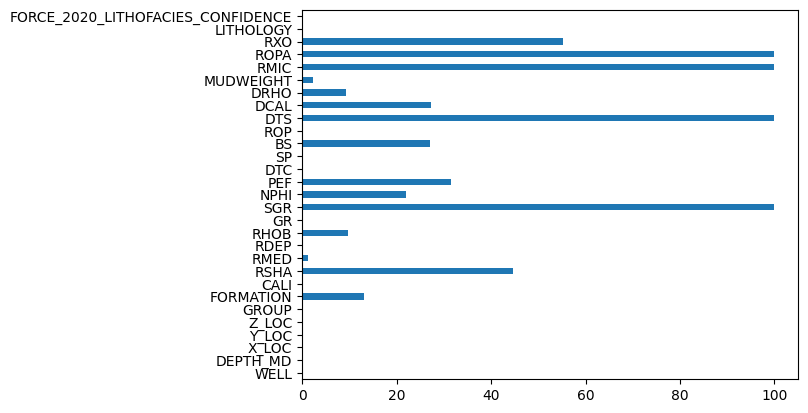

In [45]:
rowCount = len(df)


((df.isna().sum() / rowCount) * 100).plot(kind='barh')
plt.show()


LITHOLOGY
Sandstone/Shale    43734
Sandstone          10426
Dolomite            5235
Shale               3725
Marl                1953
Limestone           1171
Coal                 505
Halite               500
Chalk                323
Tuff                 103
Basement              49
Anhydrite             20
Name: count, dtype: int64
Axes(0.125,0.11;0.775x0.77)


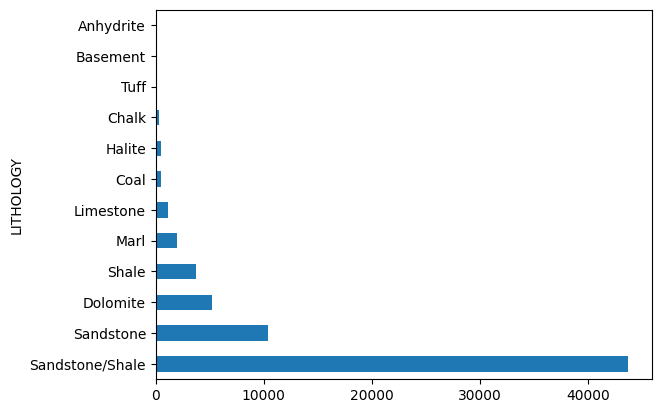

In [46]:

y = df[target].value_counts().rename(index=lithology_labels)
print(y)
print(y.plot(kind='barh'))

In [85]:


def plot_histograms(df,features):
    fig, ax = plt.subplots(1, len(features),figsize=(25,7))
    for i, feature in enumerate(features):
        ax[i].hist(df[feature],bins=30,alpha=0.7,linewidth=1.2,edgecolor='black')
        ax[i].set_title(feature)
    fig.suptitle("Dataframe Histogram")
    plt.tight_layout()
    plt.show()

def plot_wells_histograms(df,wells,features):
    for well in wells:
        aux = df[df['WELL'].isin([well])]
        fig, ax = plt.subplots(1, len(features),figsize=(25,7))
        for i, feature in enumerate(features):
            ax[i].hist(aux[feature],bins=30,alpha=0.7,linewidth=1.2,edgecolor='black')
            ax[i].set_title(feature)
        fig.suptitle(f"Well {well}")
        plt.tight_layout()
        plt.show()
    
def plot_wells_curves(df,wells,features,hub):
    for well in wells:
        aux = df[df['WELL'].isin([well])]
        fig, ax = plt.subplots(1, len(features),figsize=(20,10),sharey=True)
        for i, feature in enumerate(features):

            # if feature == "RDEP" or feature == "RMED":
            #     ax[i].set_xscale("log")
            if i == 0:
                ax[i].invert_yaxis()
            if feature == hub:
                for j in aux[feature].unique():
                    where = aux[feature] == j
                    color = lithology_colors[j]
                    ax[i].fill_betweenx(aux[index],0,1,where=where,color=color,alpha=0.09)
            if feature != hub:
                ax[i].plot(aux[feature],aux[index])
            ax[i].set_title(feature)
        fig.suptitle(f"Well {well}")
        plt.tight_layout()
        plt.show()




In [86]:
print(df[features].describe())

                 GR          NPHI          RHOB           PEF          RSHA  \
count  67744.000000  52891.000000  61137.000000  46356.000000  37516.000000   
mean      67.692338      0.367816      2.159560      4.443176     34.986332   
std       31.146291      0.151919      0.277718      5.891912    224.542171   
min        5.782680     -0.013786      1.343777      1.010027      0.005141   
25%       46.666294      0.246883      1.985665      2.490828      0.716270   
50%       70.554253      0.418584      2.086197      3.350055      0.968800   
75%       87.118988      0.491104      2.396298      5.022481      1.334763   
max      804.298950      0.800262      3.054074    365.575592   1999.800049   

               RMED          RDEP           DTC  
count  66883.000000  67744.000000  67624.000000  
mean       3.298709      4.566149    123.597811  
std       38.564883     48.558624     34.985876  
min        0.181414      0.126817      7.415132  
25%        0.755775      0.742151     

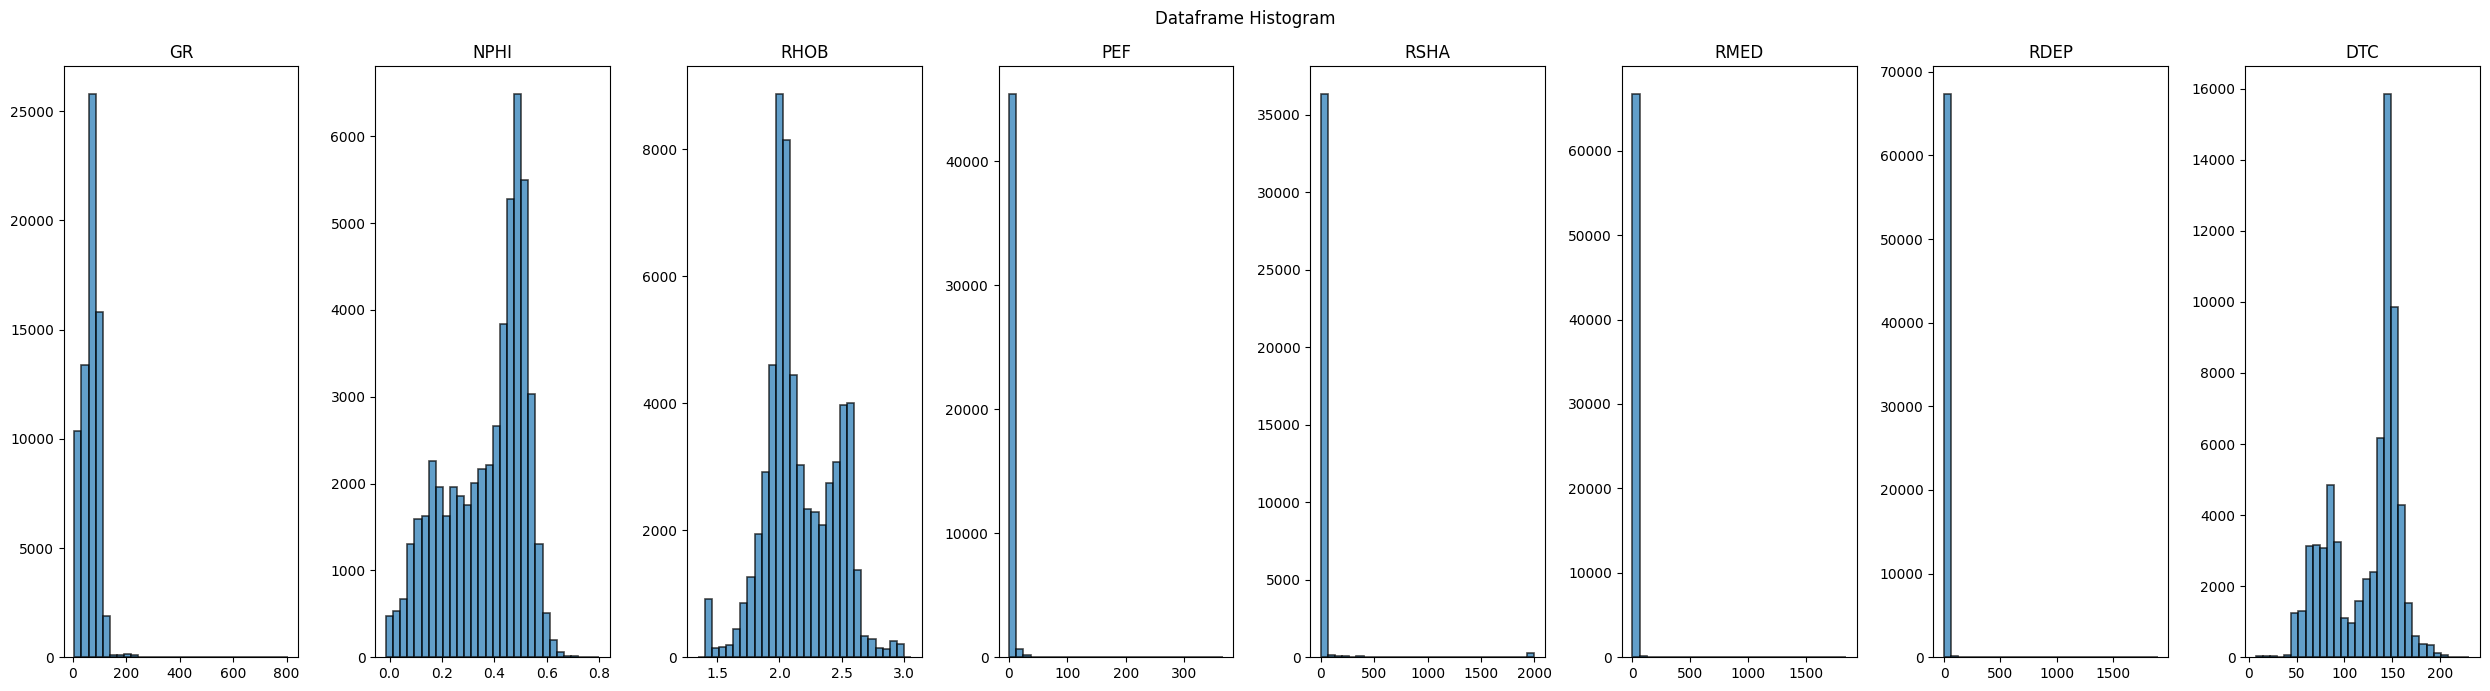

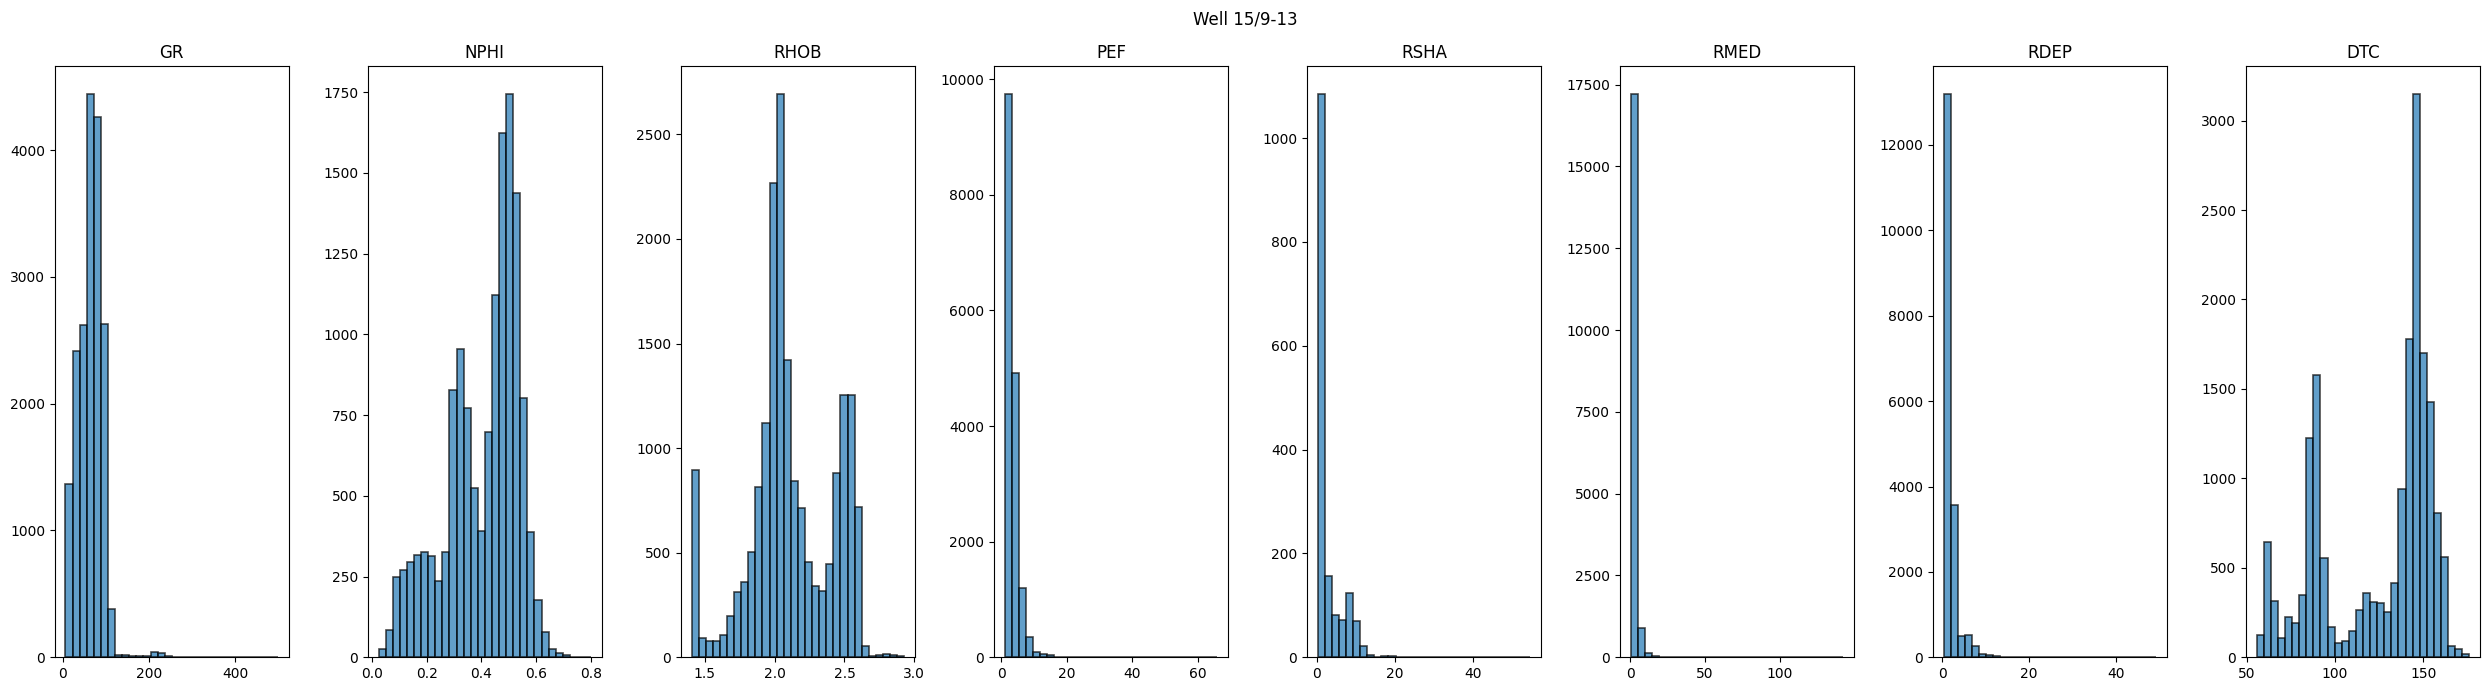

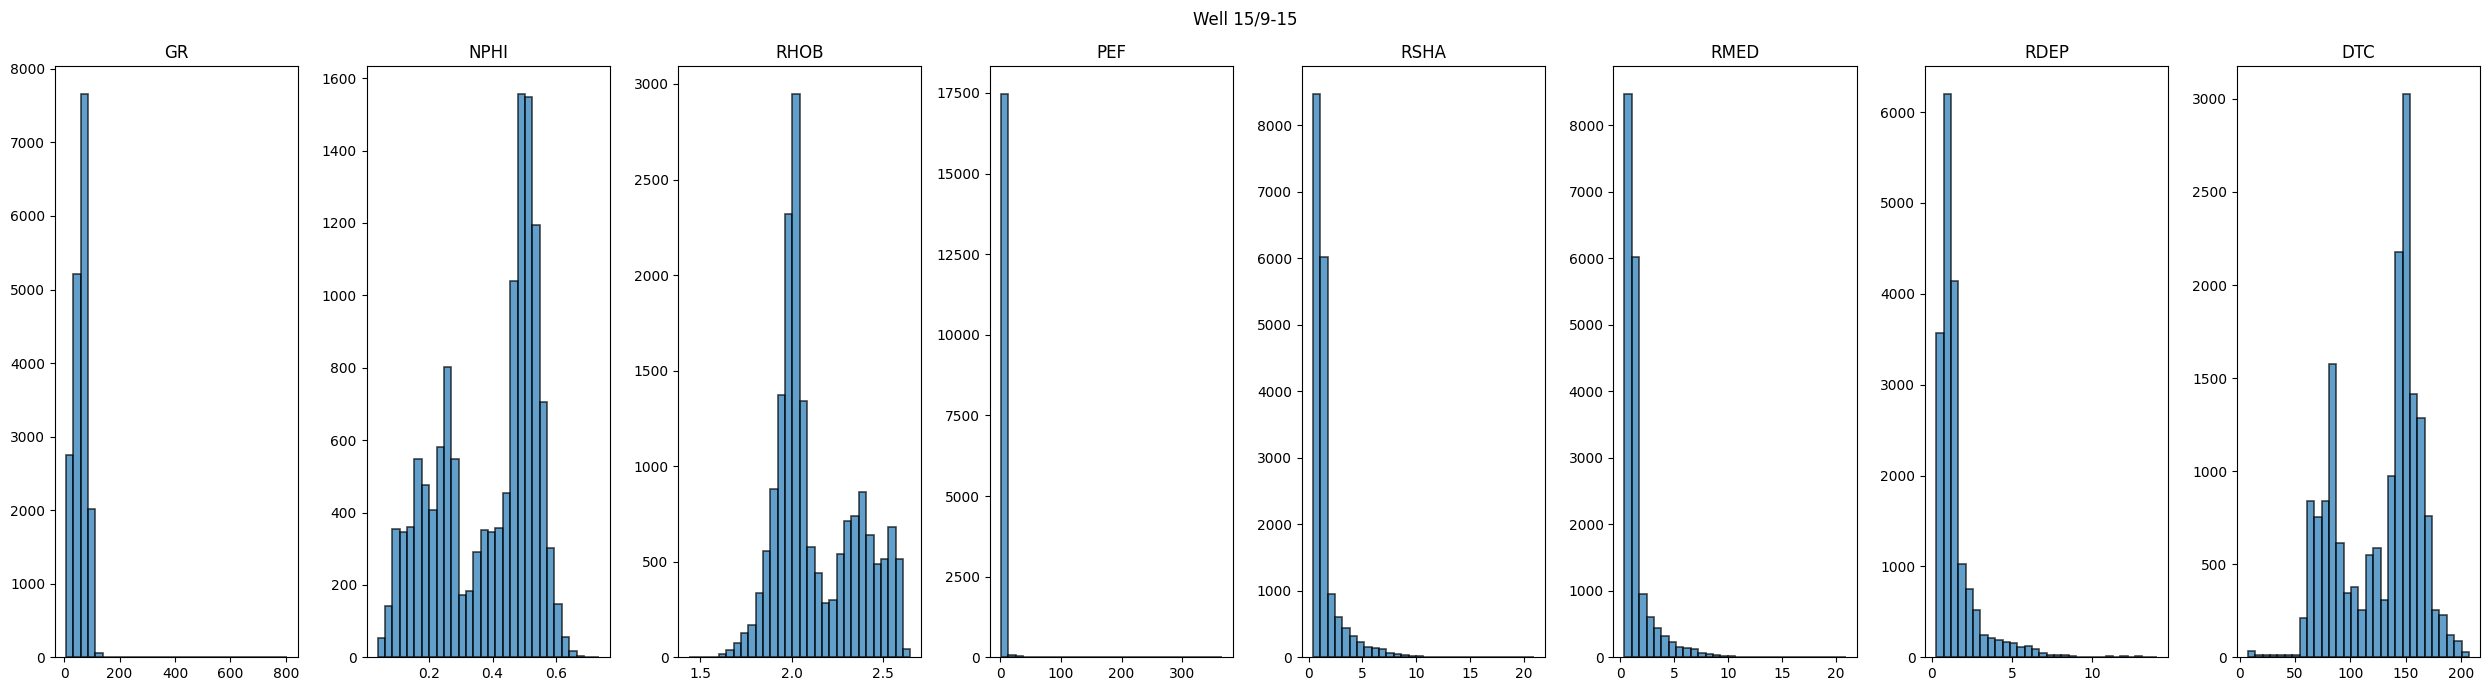

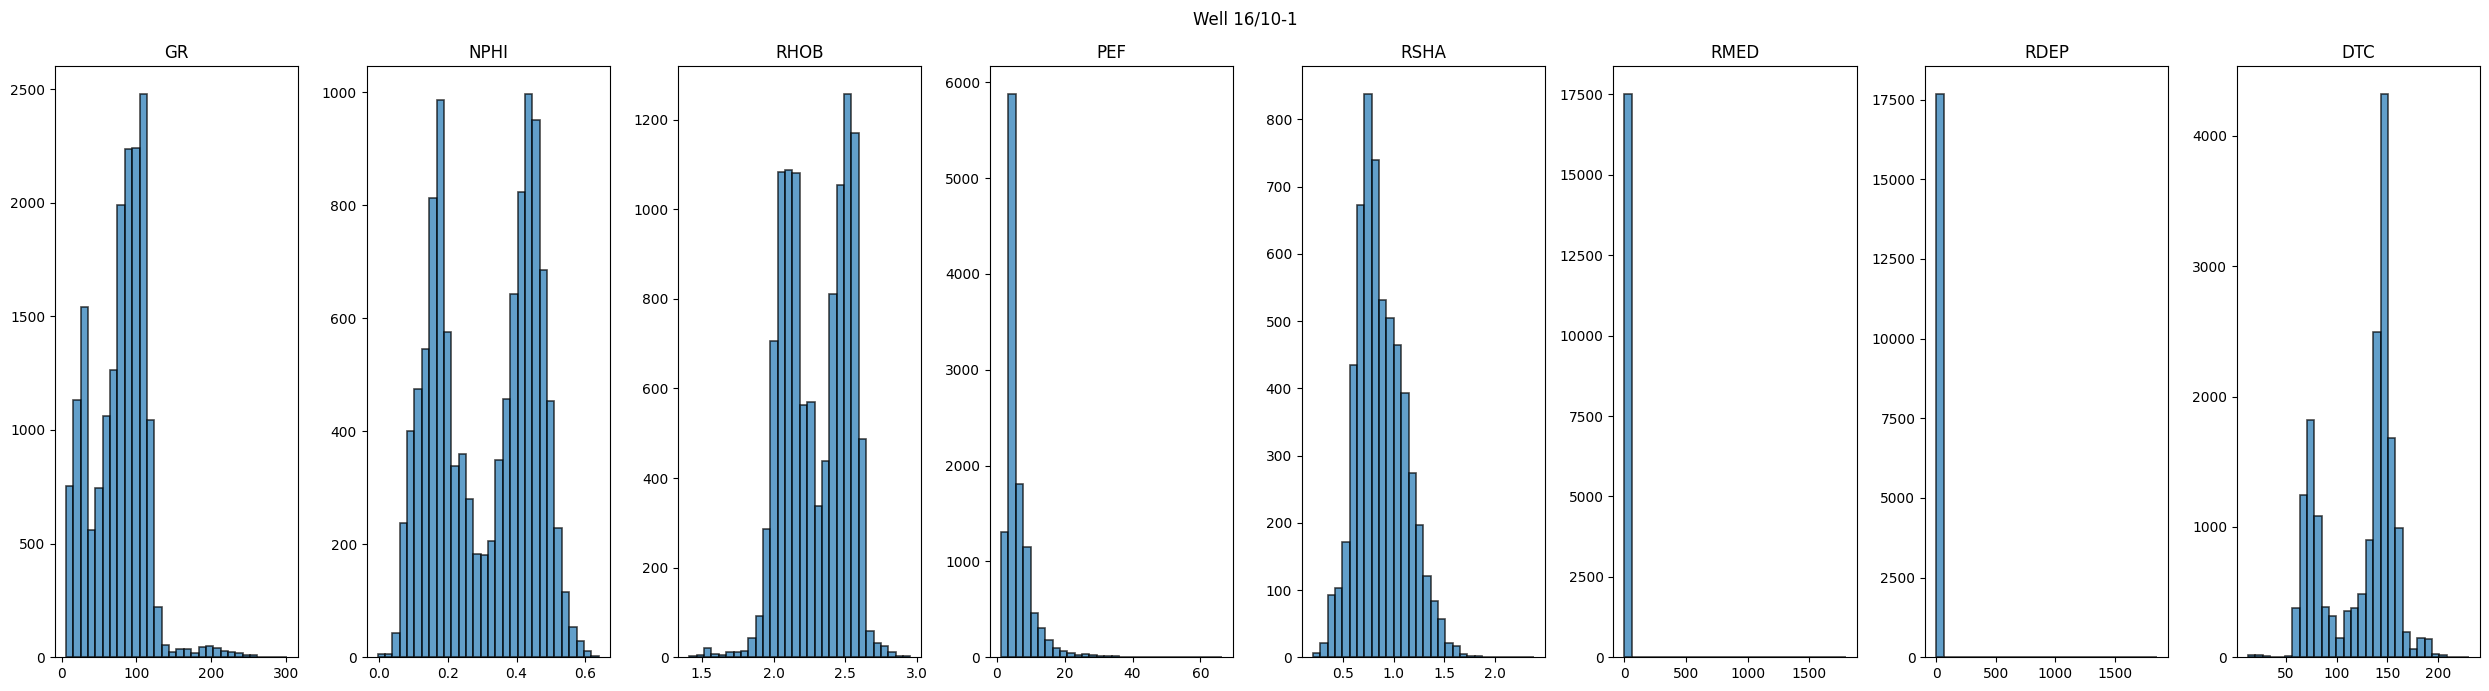

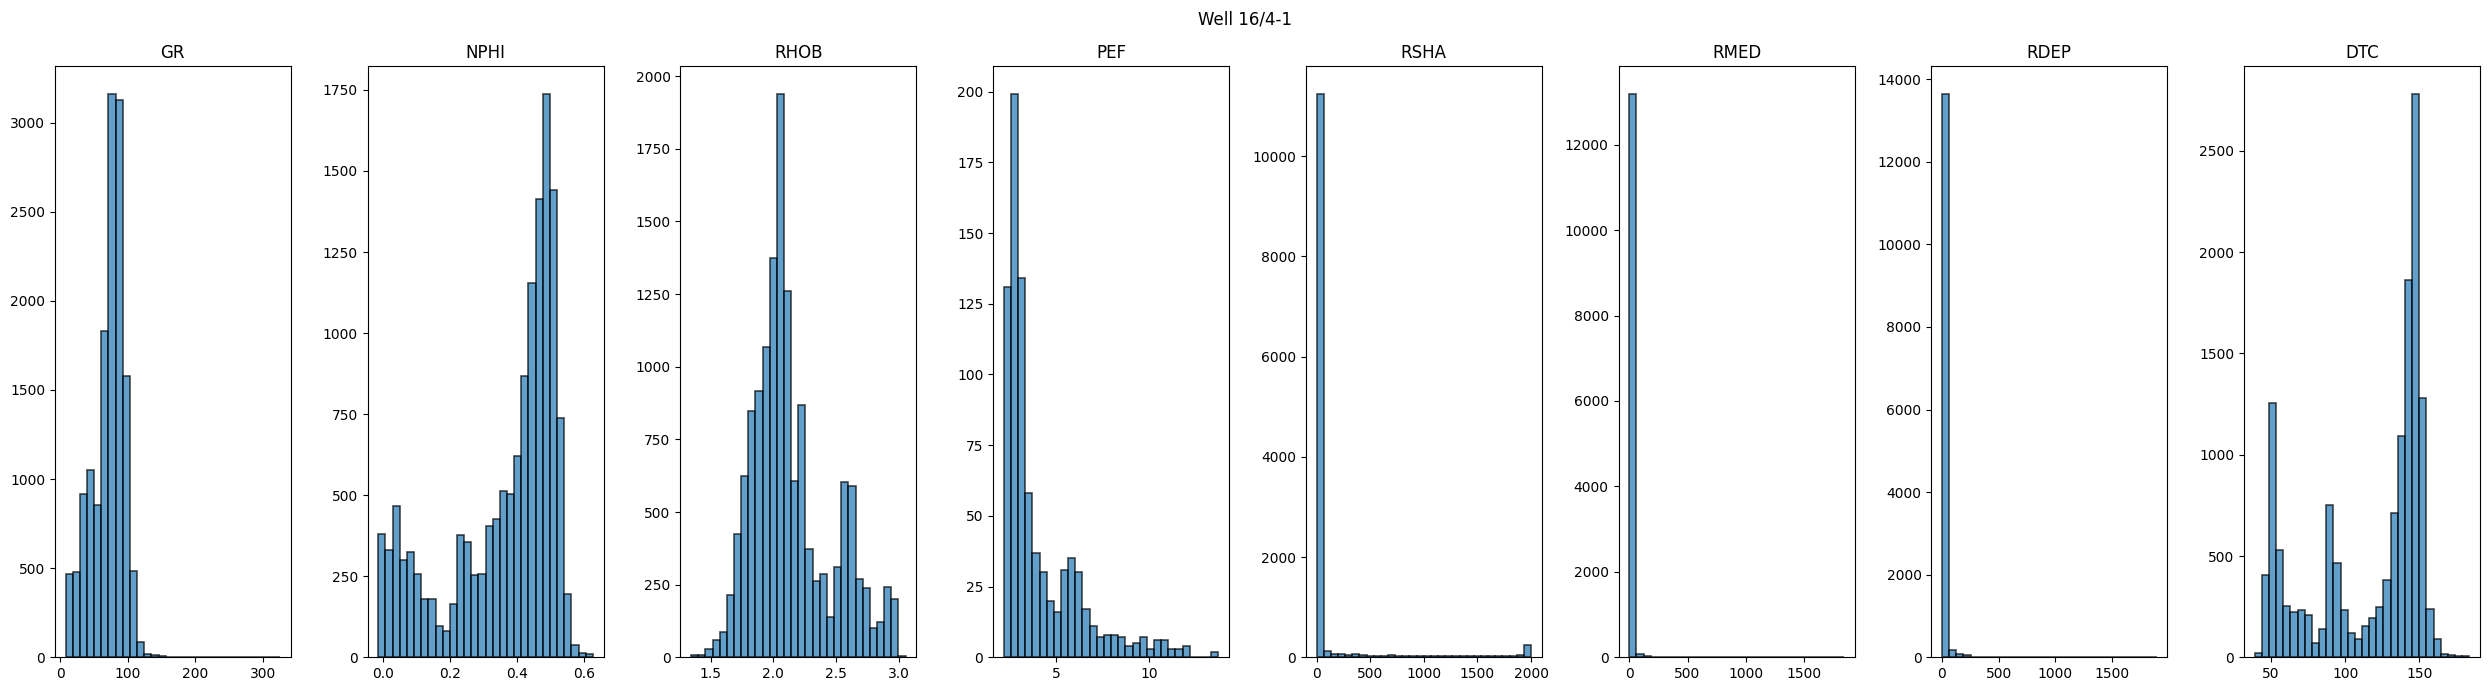

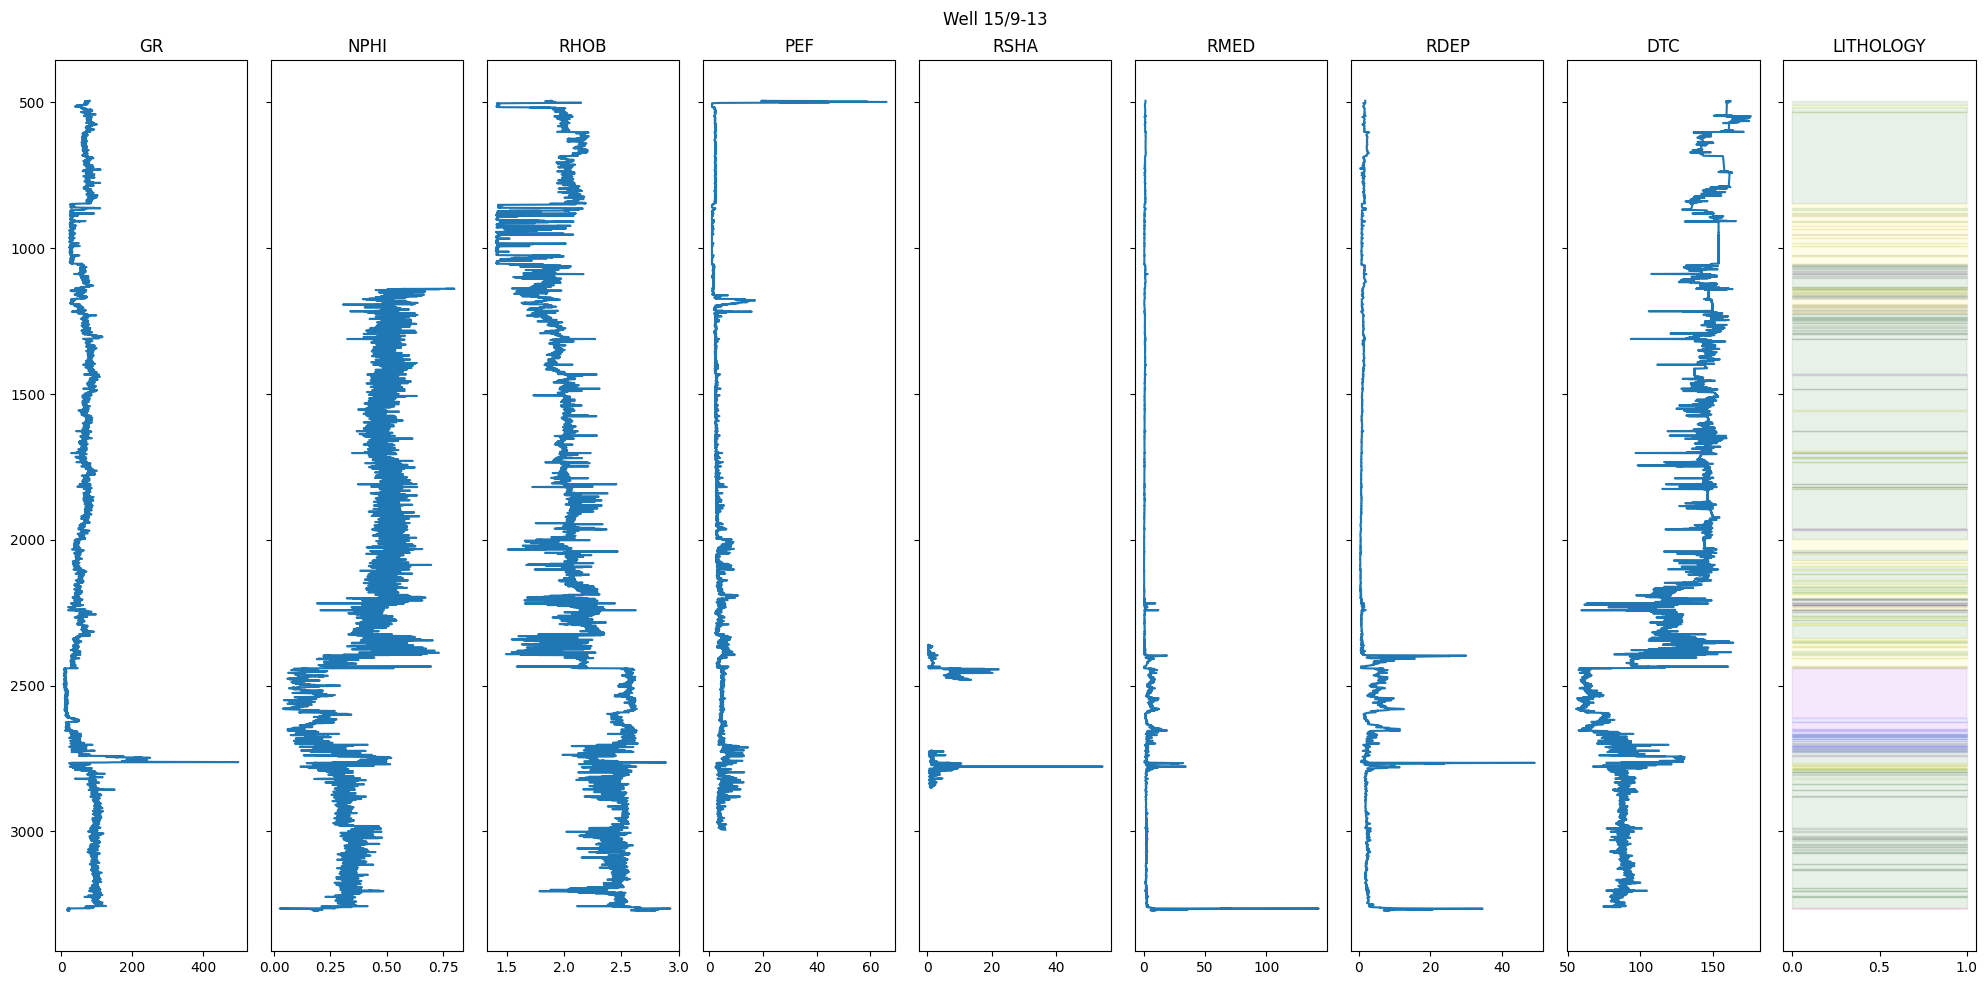

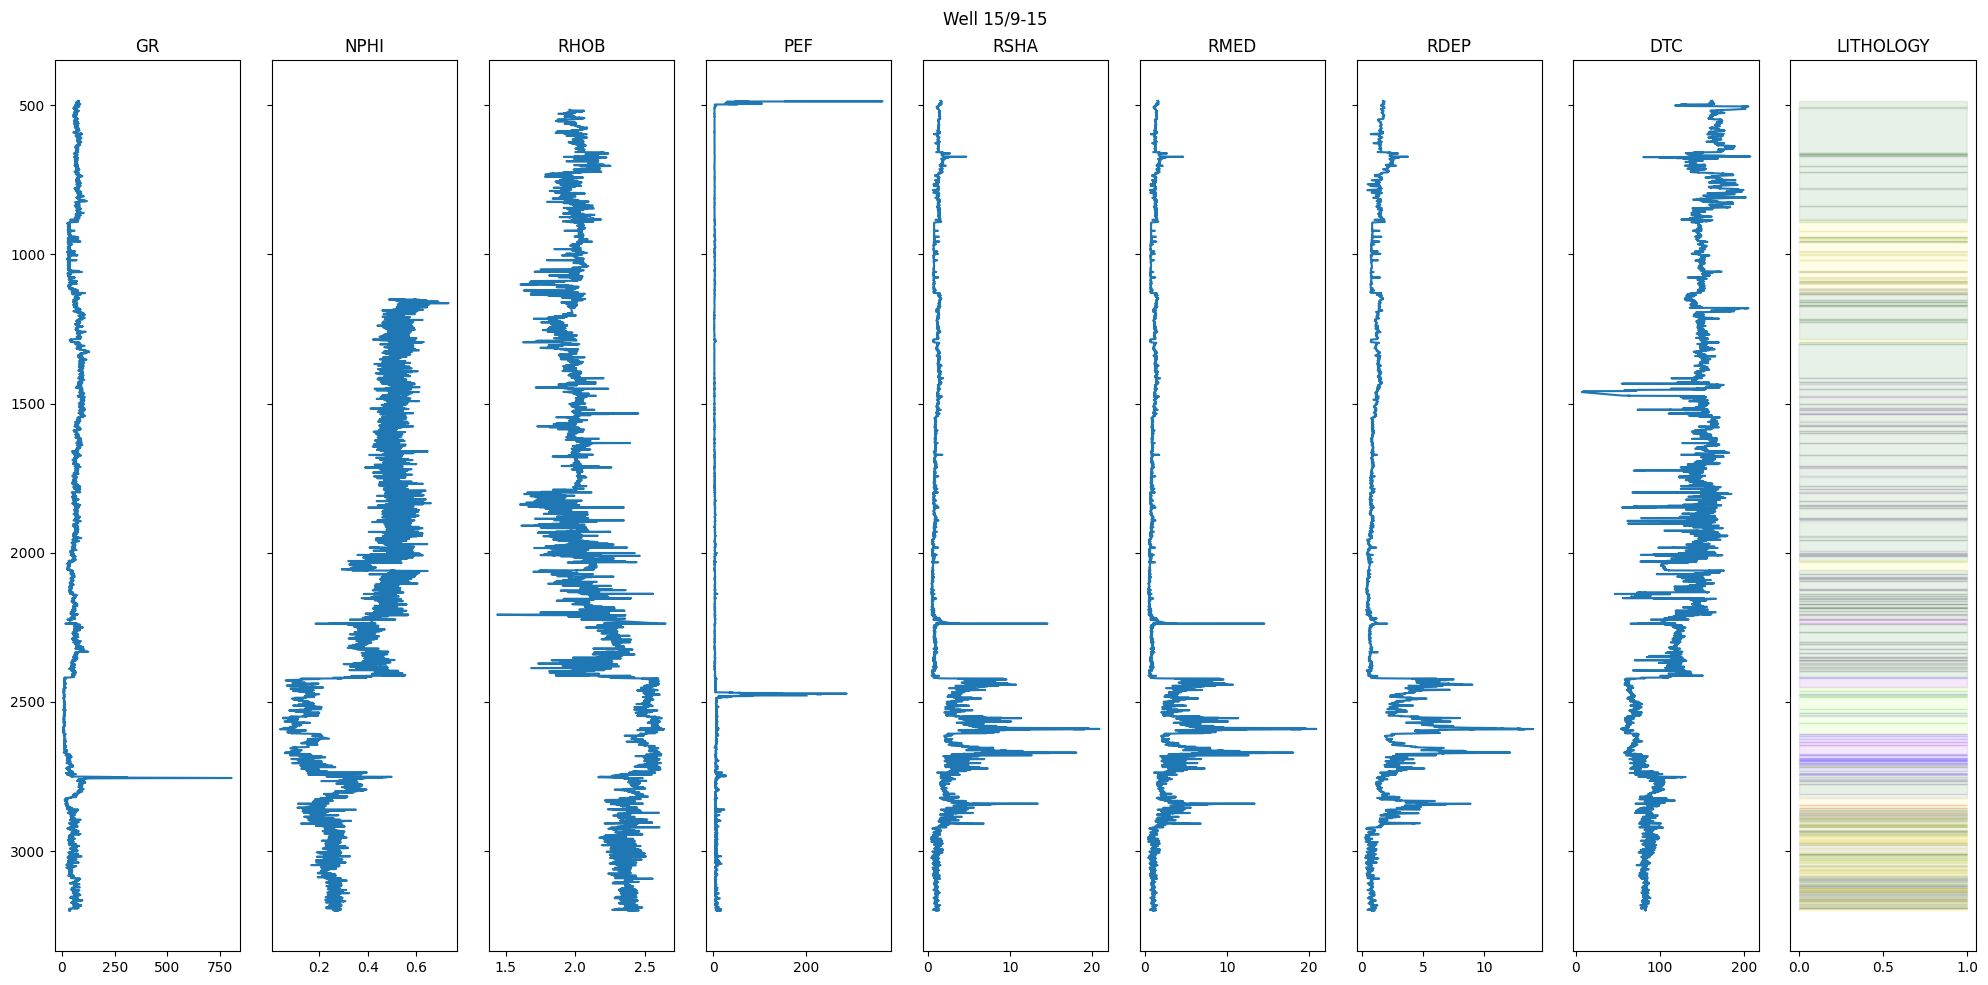

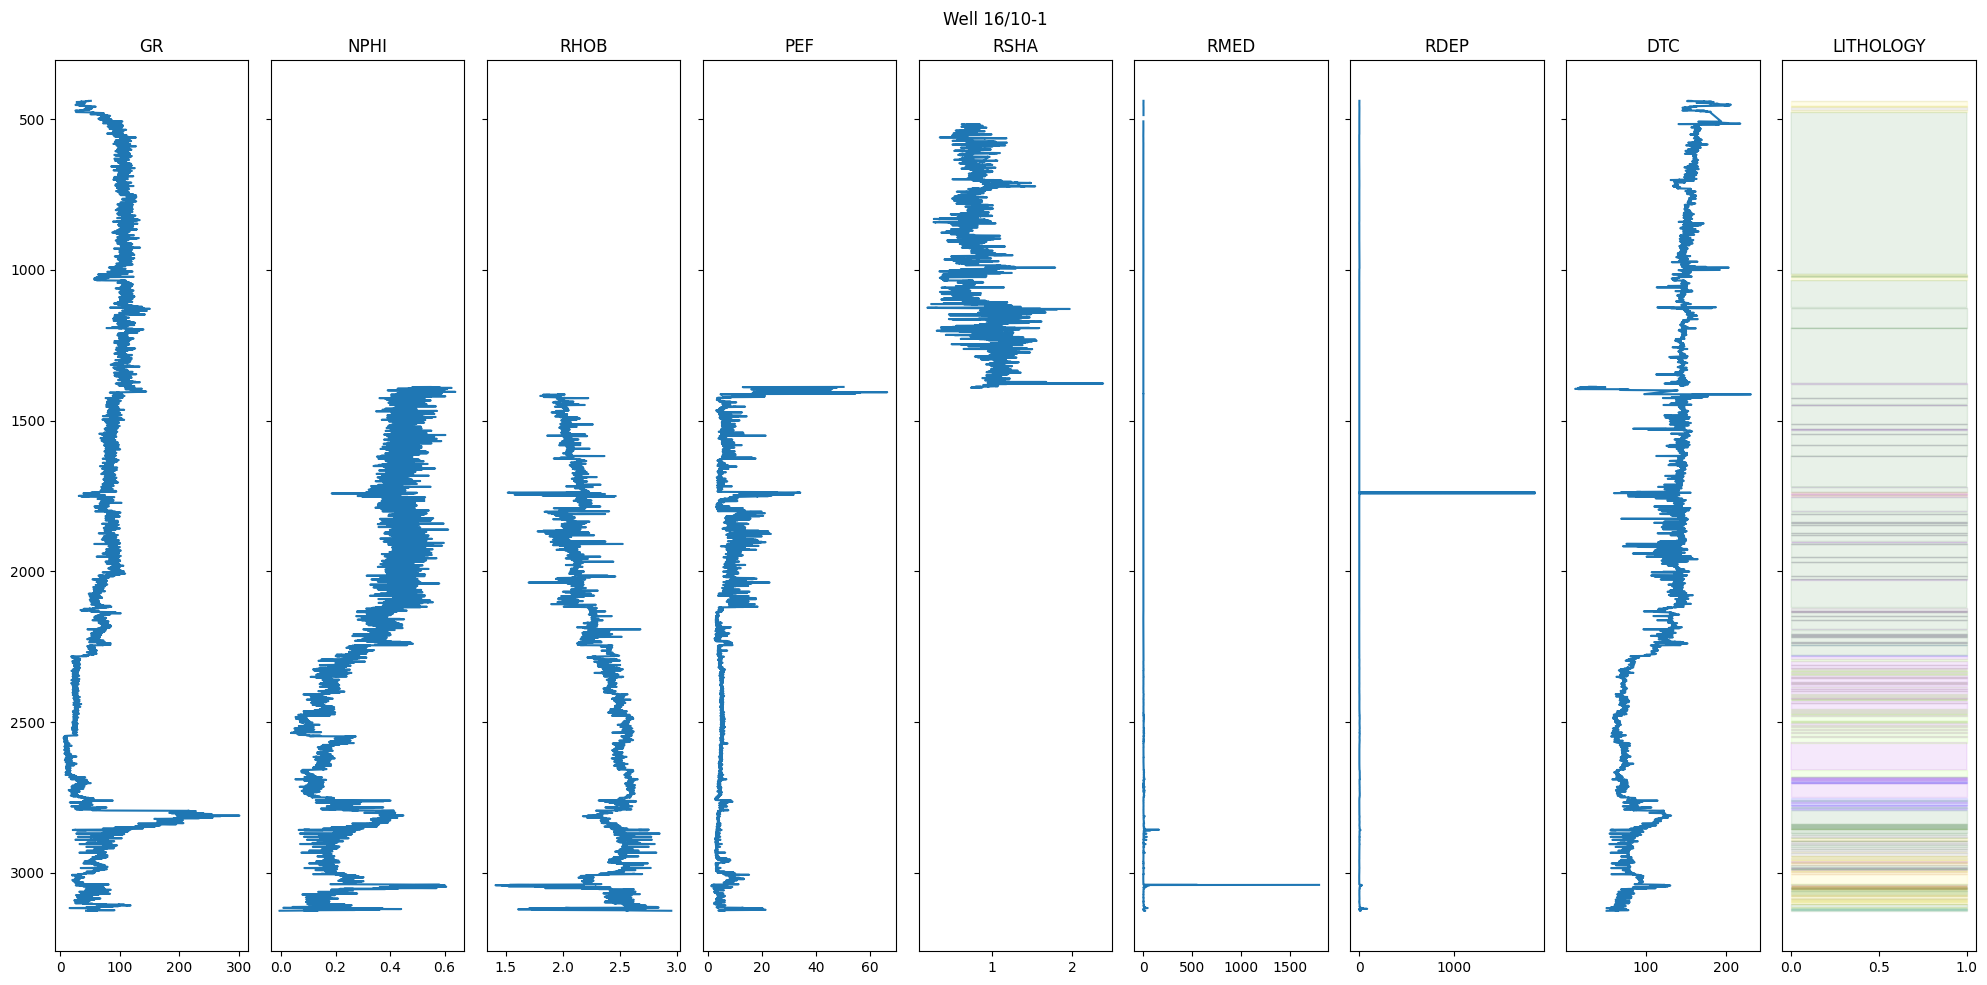

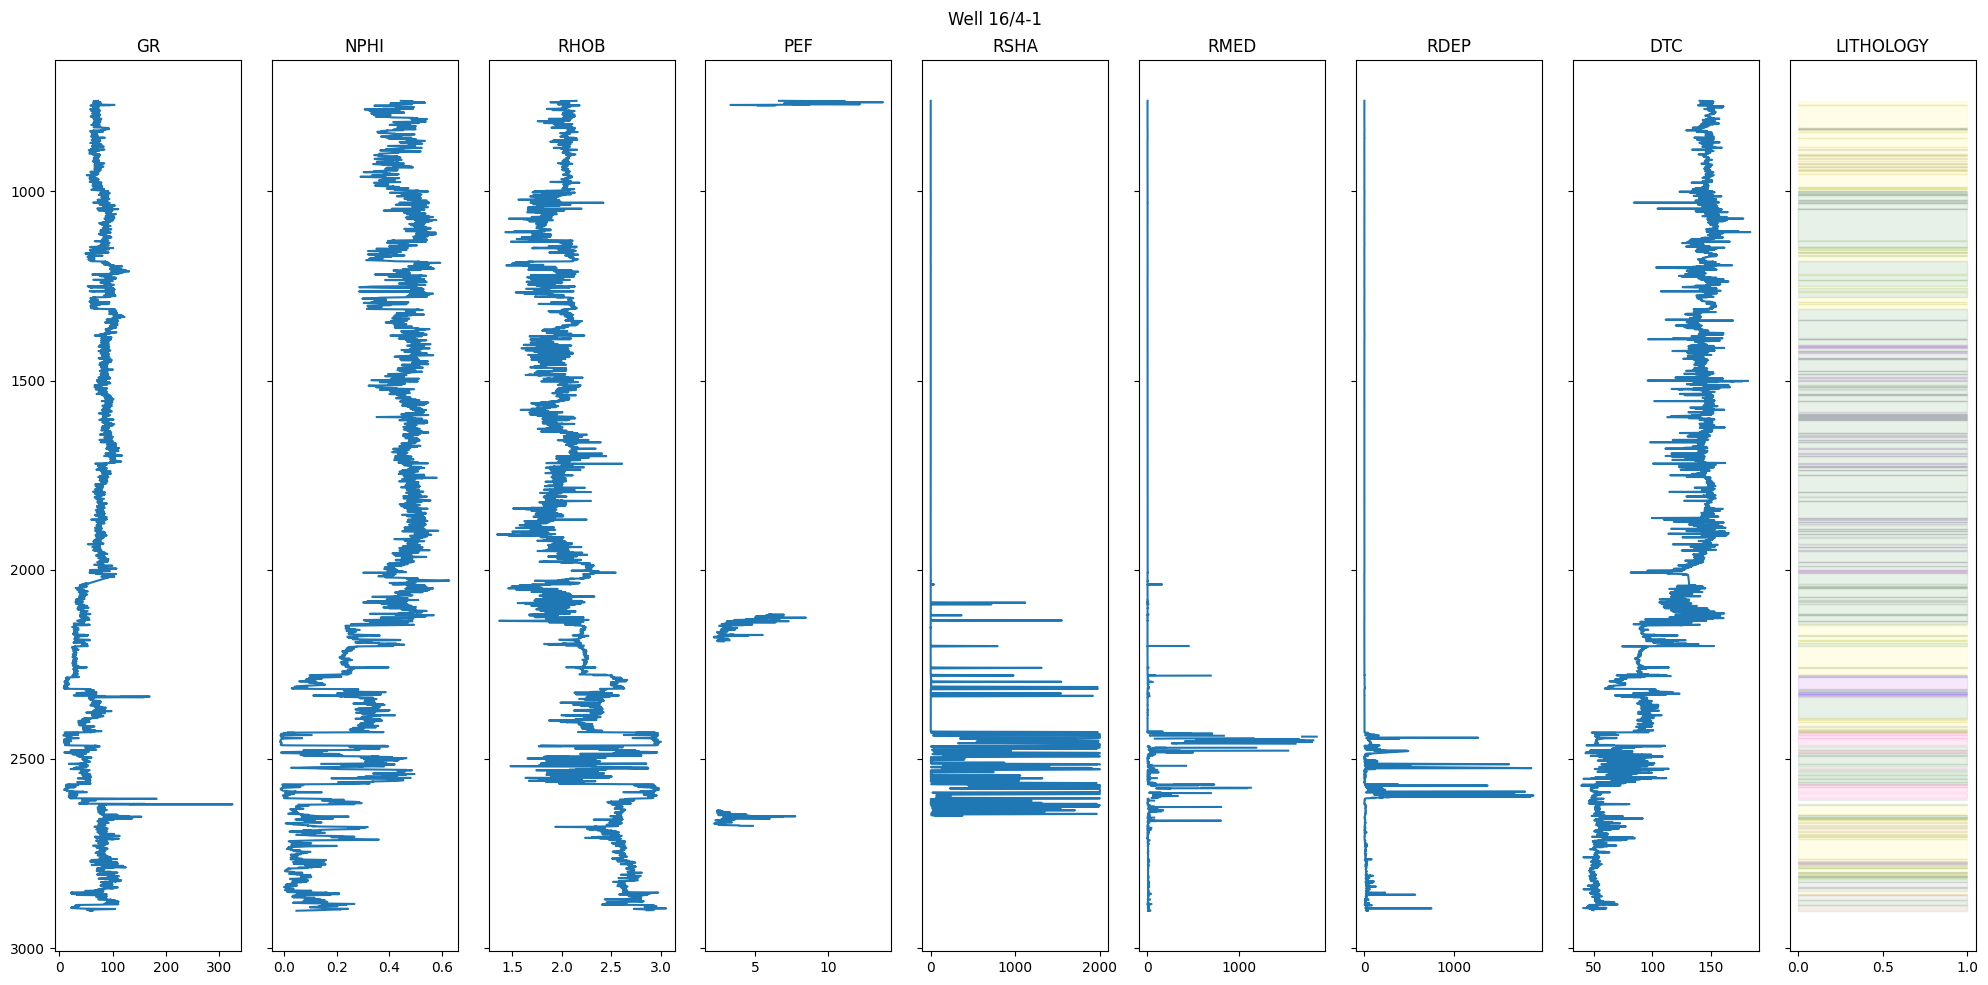

In [87]:
plot_histograms(df,features)
plot_wells_histograms(df,wells,features)
plot_wells_curves(df,wells,features + [target],target)

In [94]:
df_imputed = df.copy()

In [95]:
resistence_labels = ["RDEP",'RMED','RSHA']

df_imputed[resistence_labels] = np.log10(df_imputed[resistence_labels])

df_imputed['GR'] = df_imputed['GR'].clip(lower=0,upper=200)
df_imputed['PEF'] = df_imputed['PEF'].clip(lower=0,upper=10)

In [96]:
imputer = KNNImputer(n_neighbors=3)
# imputer = SimpleImputer()
df_imputed[features] = imputer.fit_transform(df_imputed[features])


In [118]:
scaler = StandardScaler()

df_imputed[features] = scaler.fit_transform(df_imputed[features])

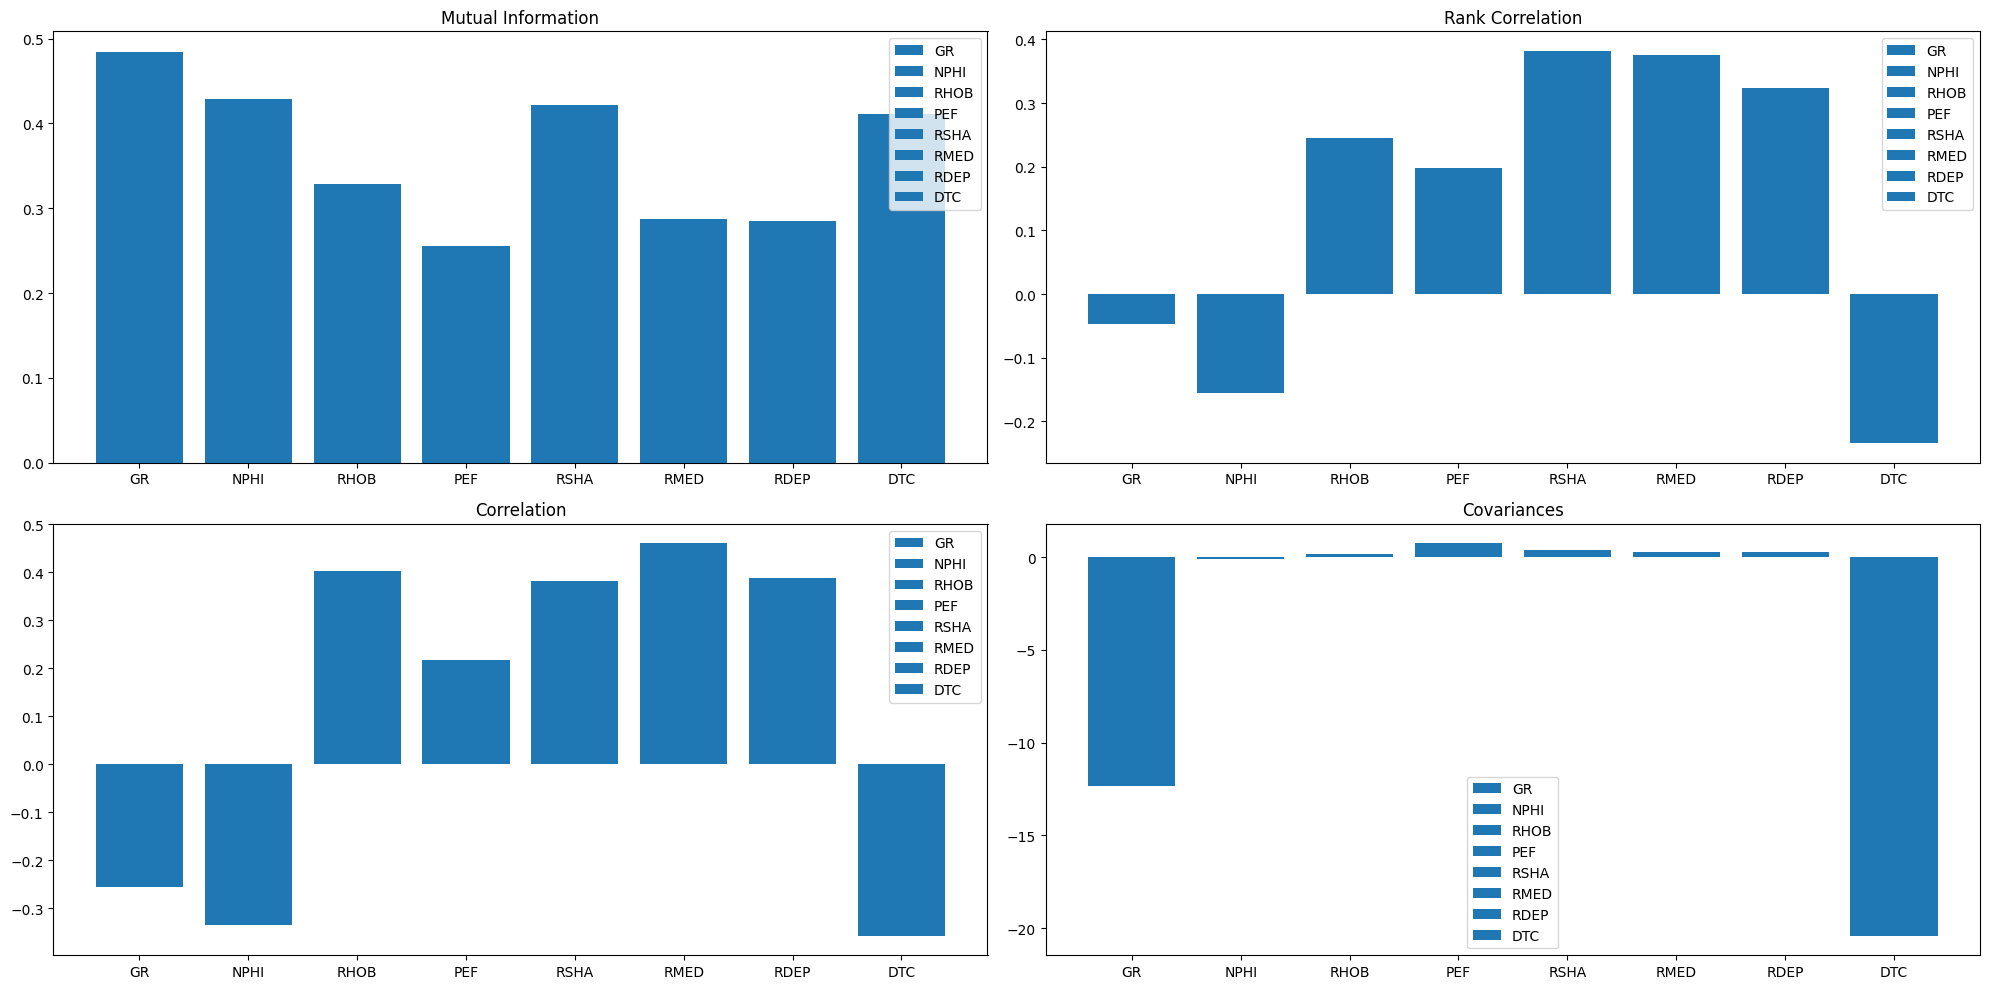

In [97]:
ranking_features = features + [target]

importances_mi  = mutual_info_classif(df_imputed[features],df_imputed[target],random_state=42)
correlations = df_imputed[ranking_features].corr(method="pearson")[target].drop([target])
rank_correlations = df_imputed[ranking_features].corr(method="spearman")[target].drop([target])
covariance = df_imputed[ranking_features].cov()[target].drop([target])


rankings_methods = {
    "Mutual Information": importances_mi,
    "Correlation": correlations.values,
    "Rank Correlation": rank_correlations.values,
    "Covariances": covariance.values
}



fig, ax = plt.subplots(2,2,figsize=(20,10))

row = 0
col = 0
for i,method in enumerate(rankings_methods):
  if col == 2:
    col = 0
    row+=1
  ax[col][row].bar(features,rankings_methods[method],label=features)
  ax[col][row].set_title(method)
  ax[col][row].legend()
  col+=1



plt.tight_layout()
plt.show()

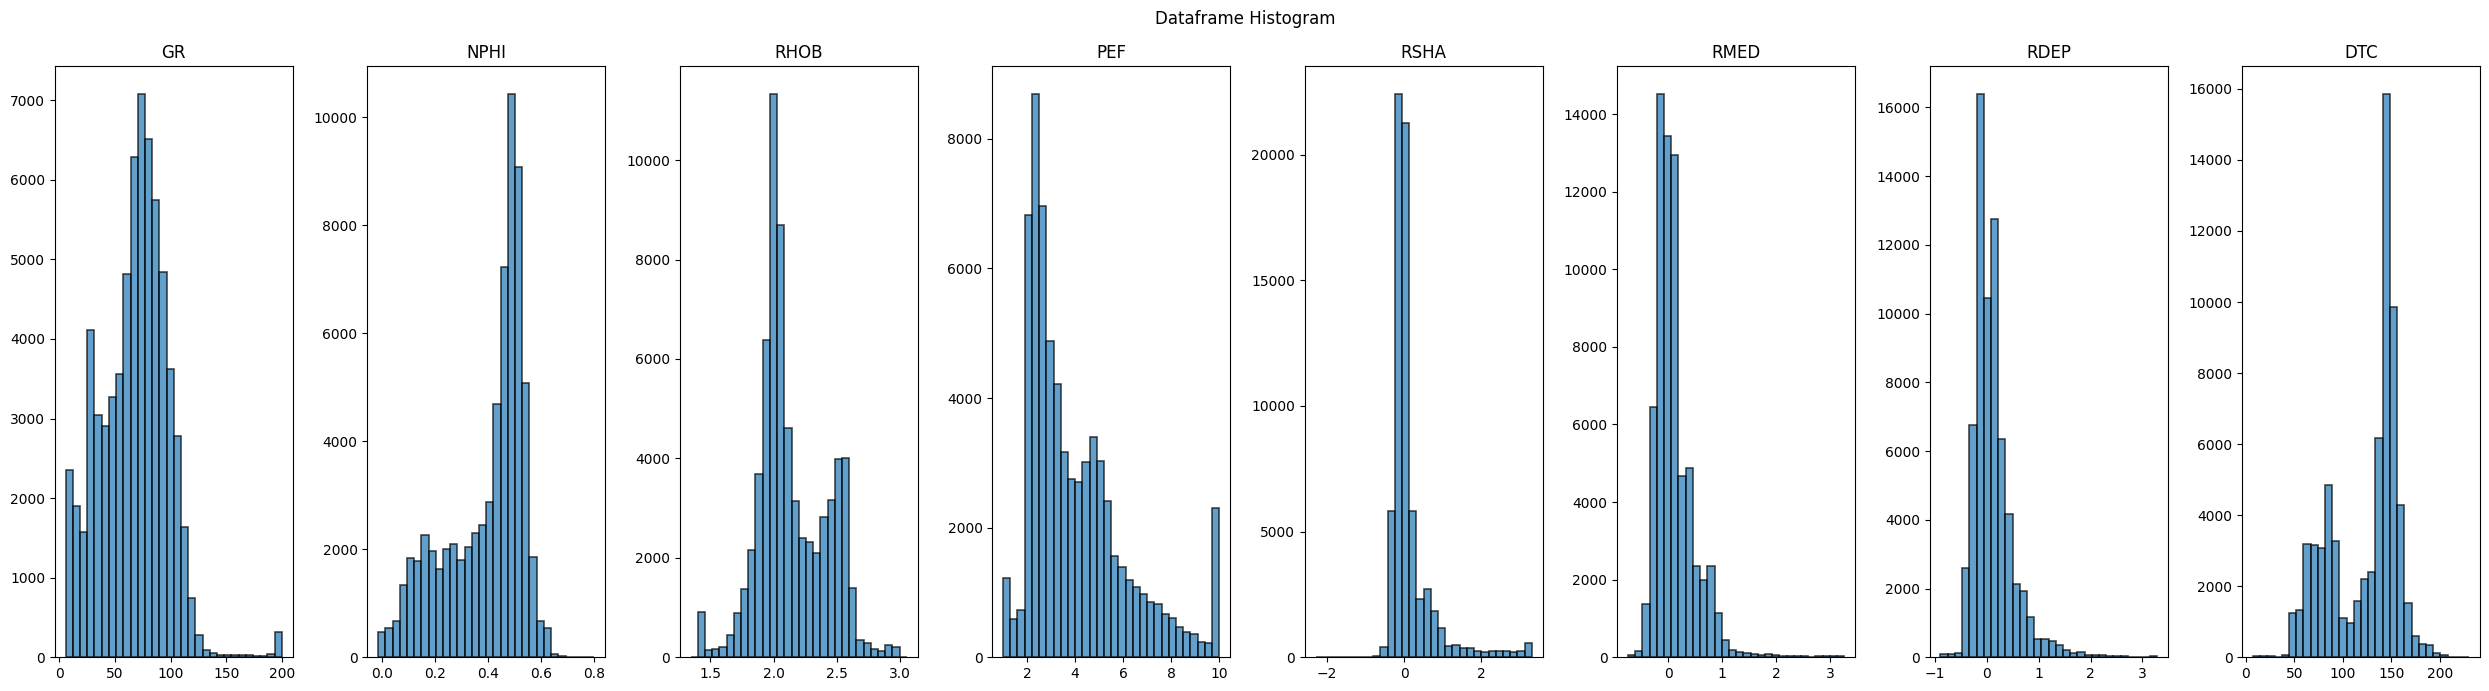

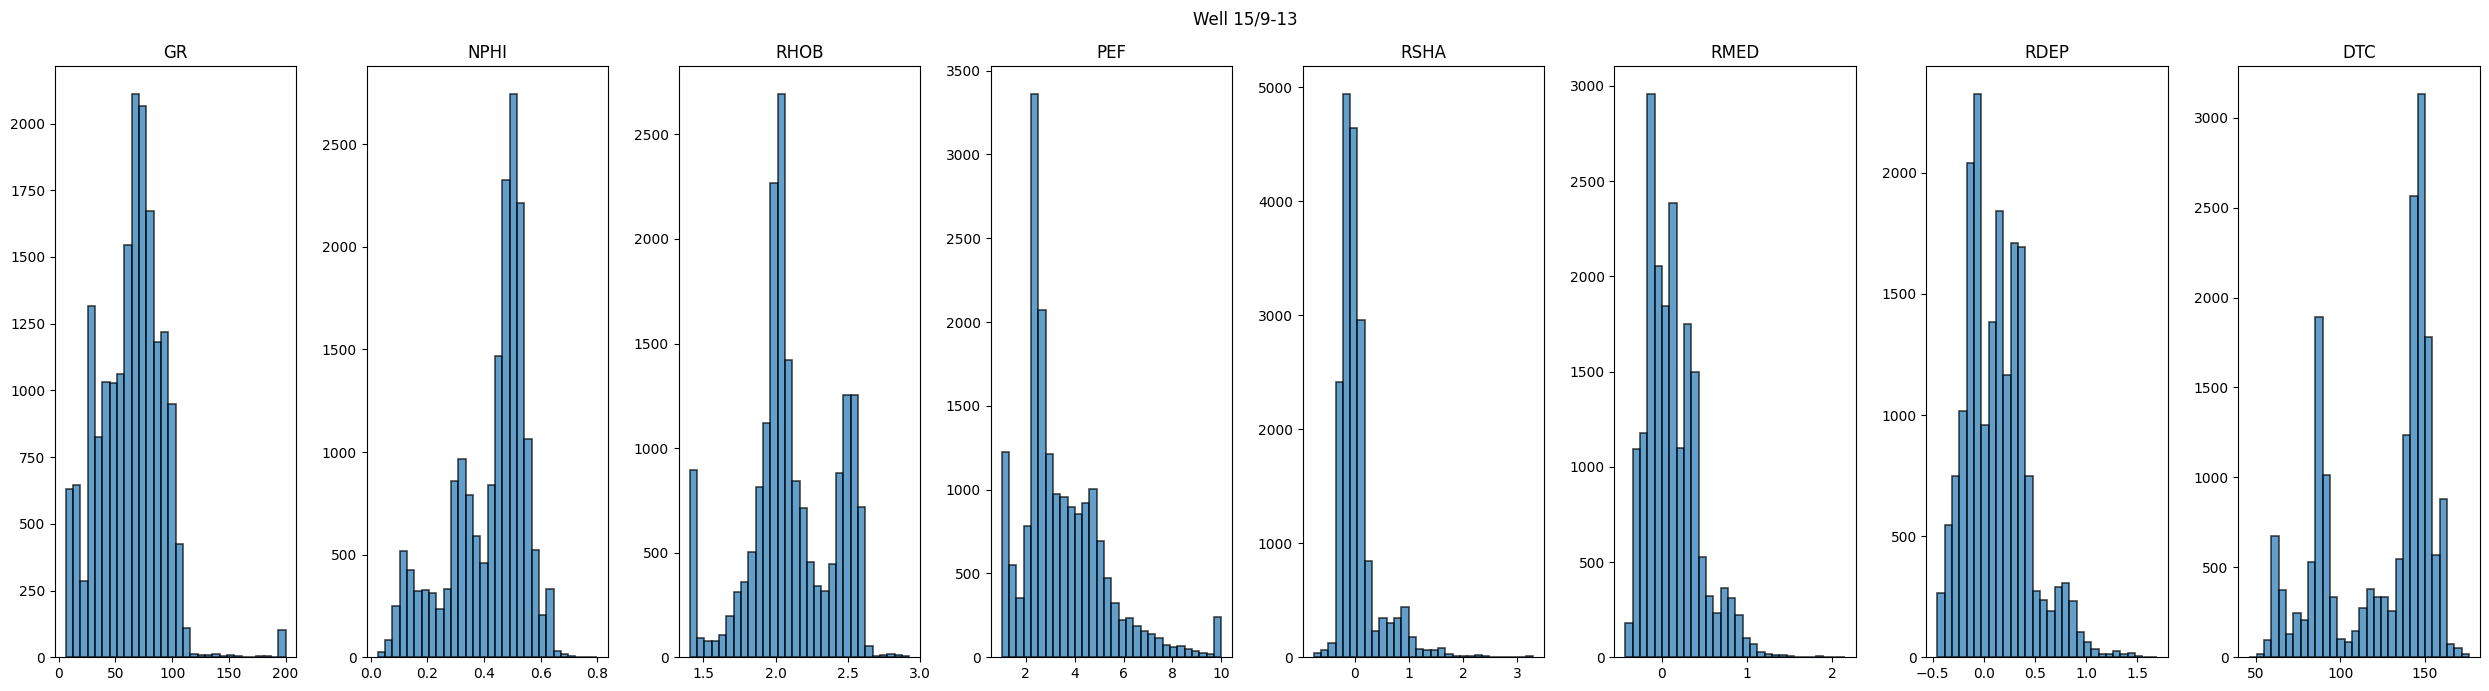

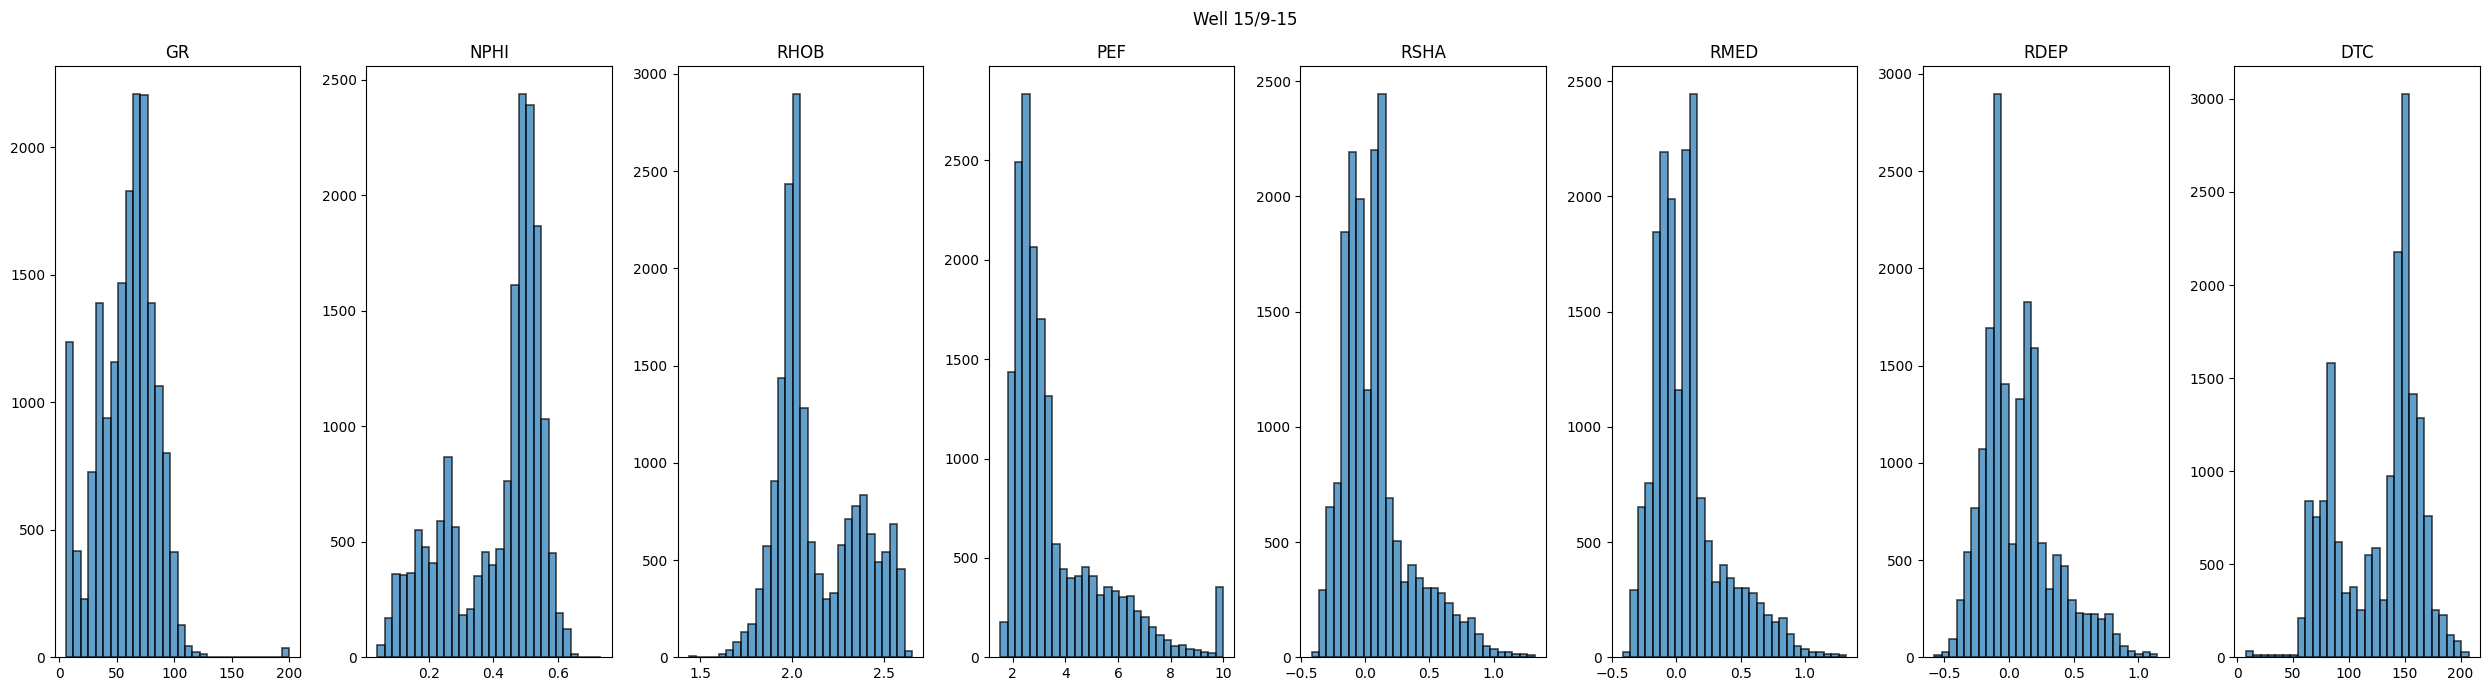

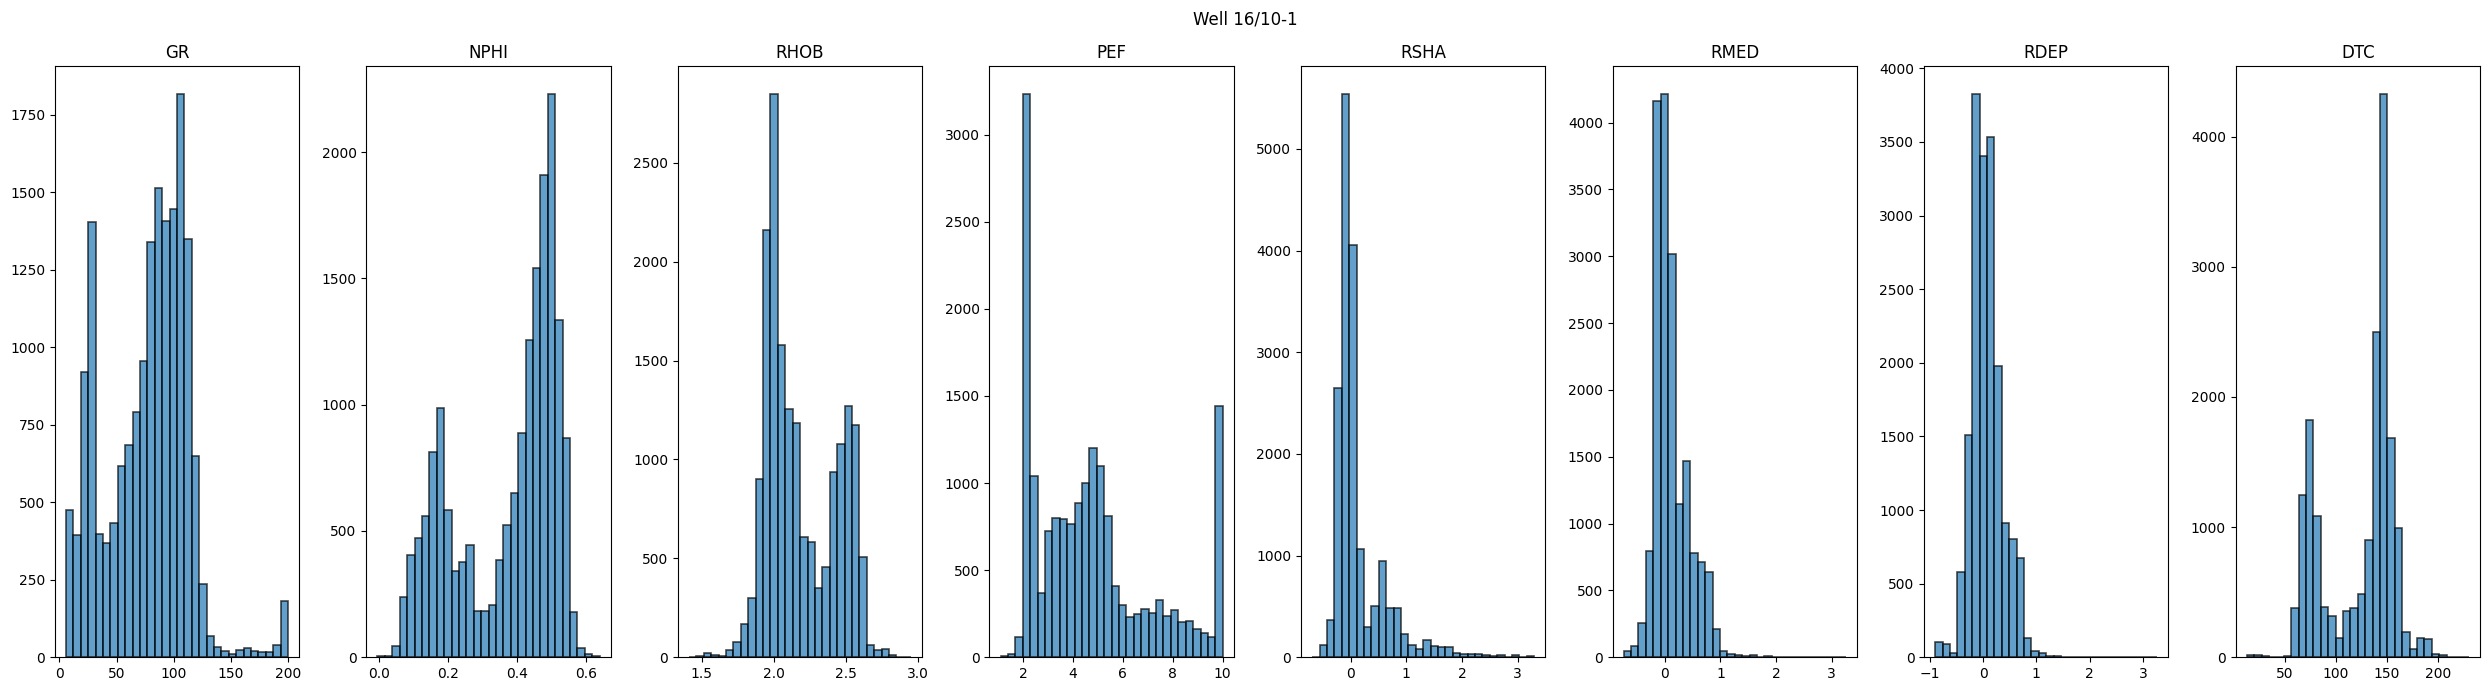

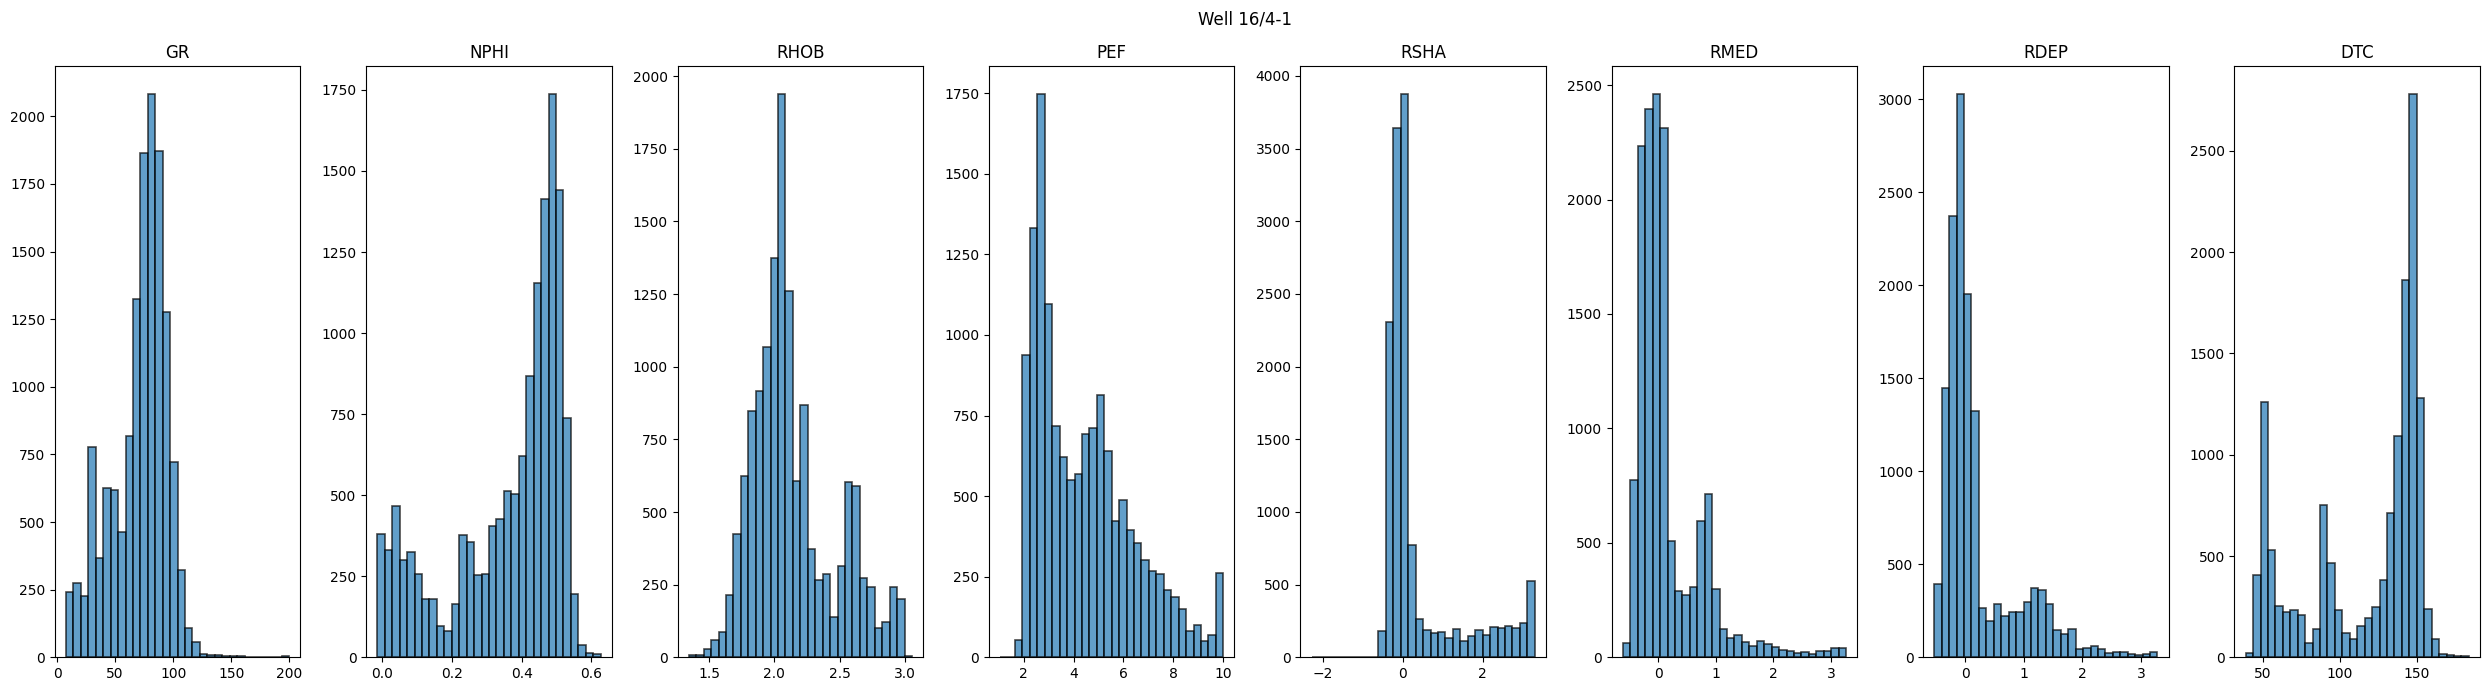

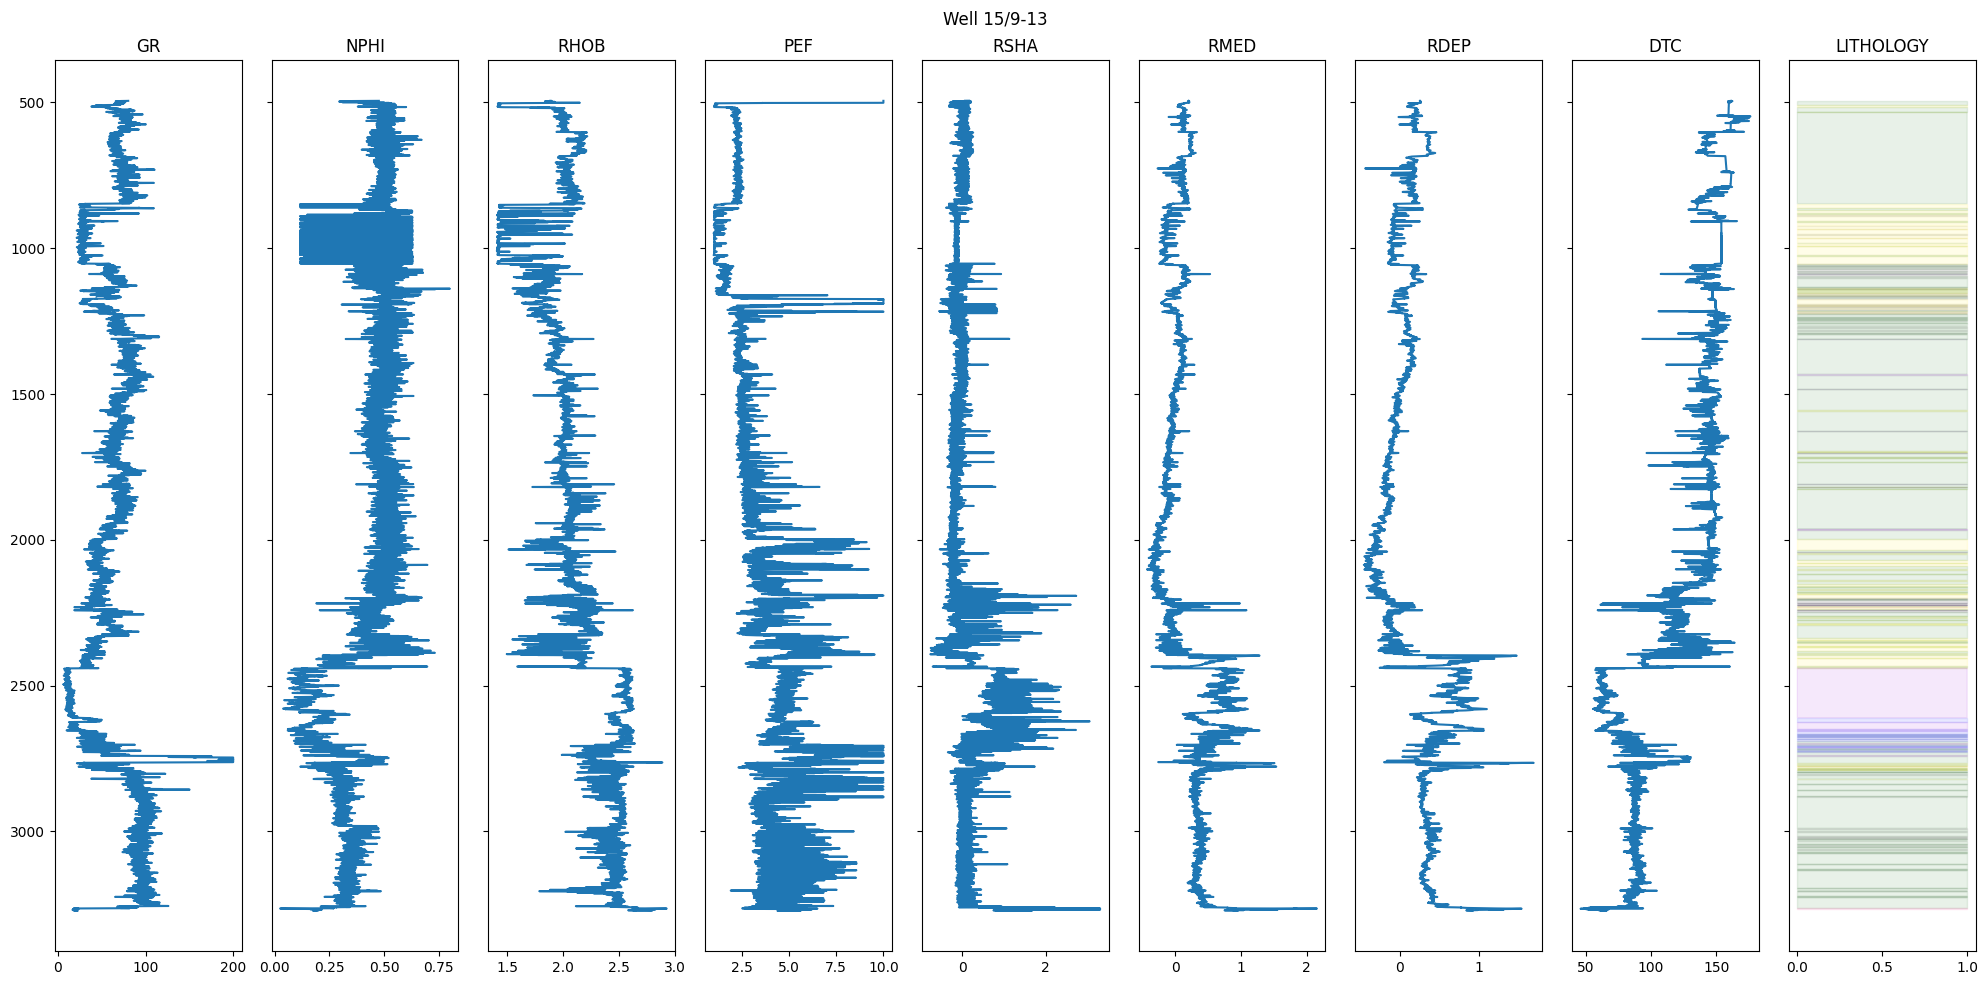

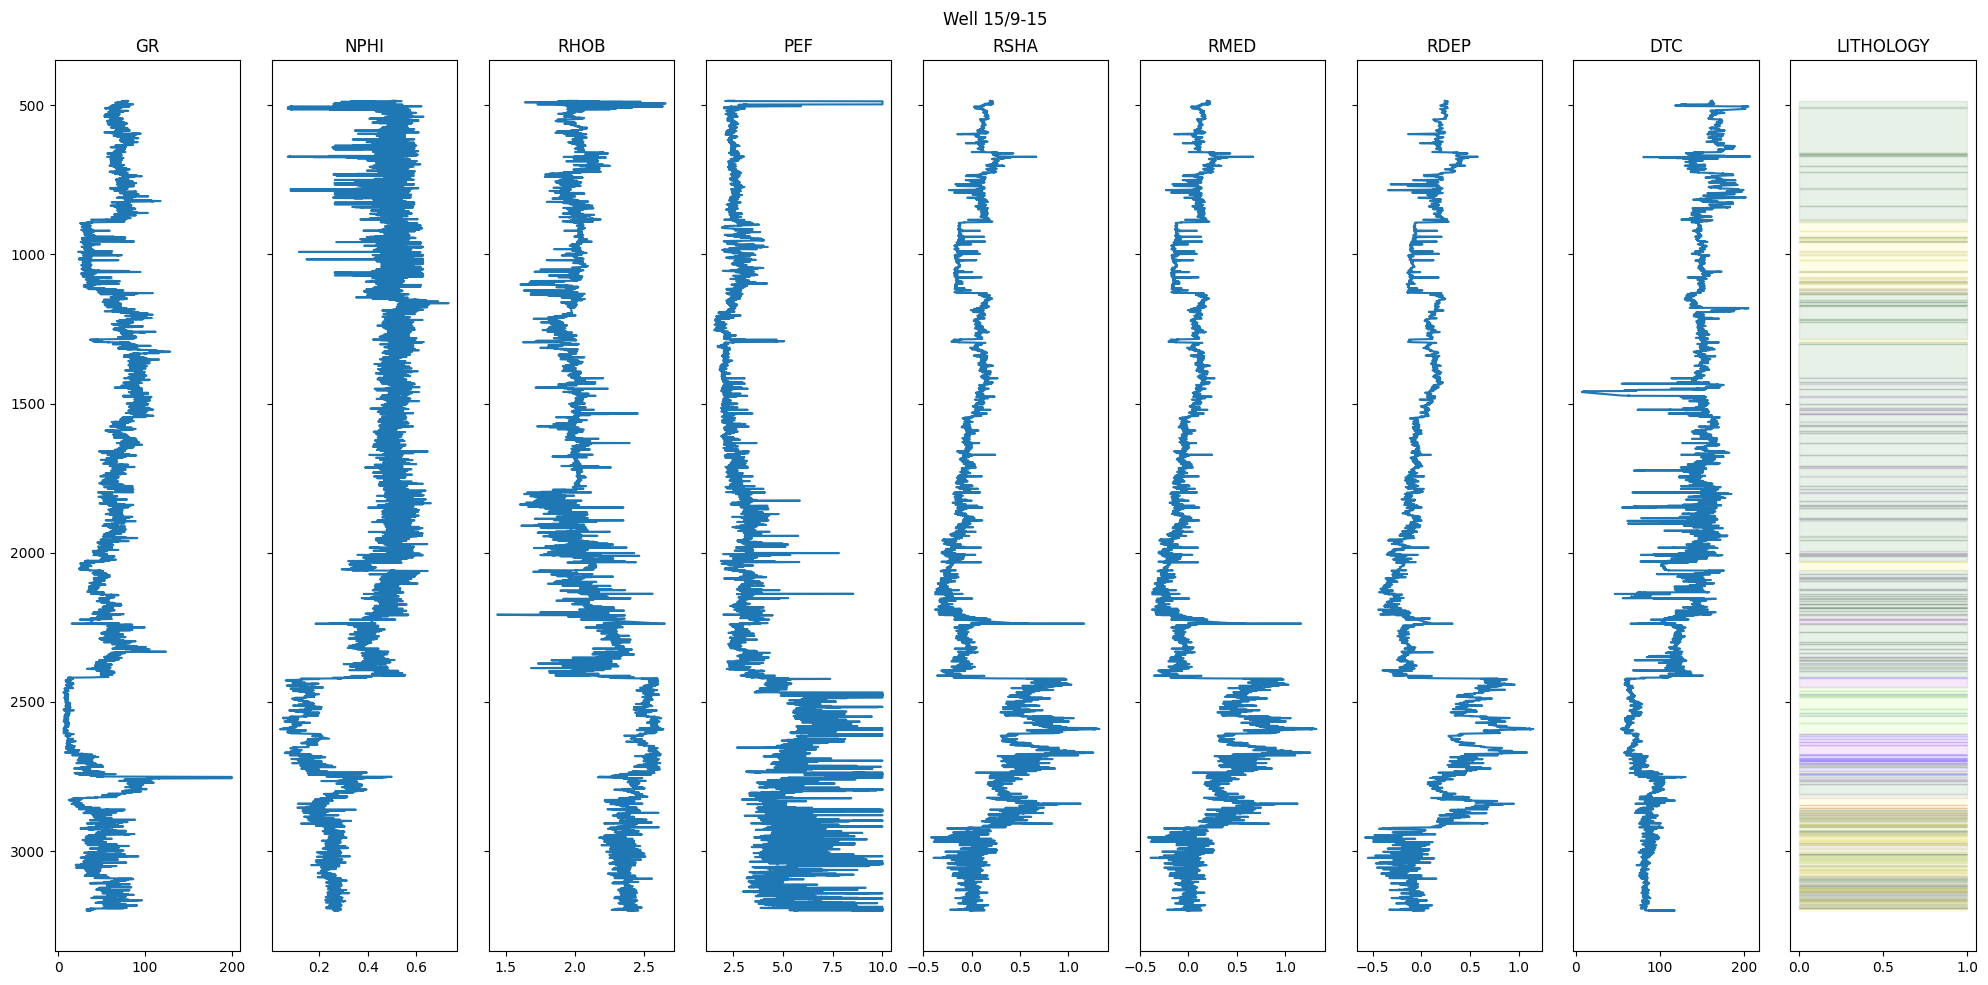

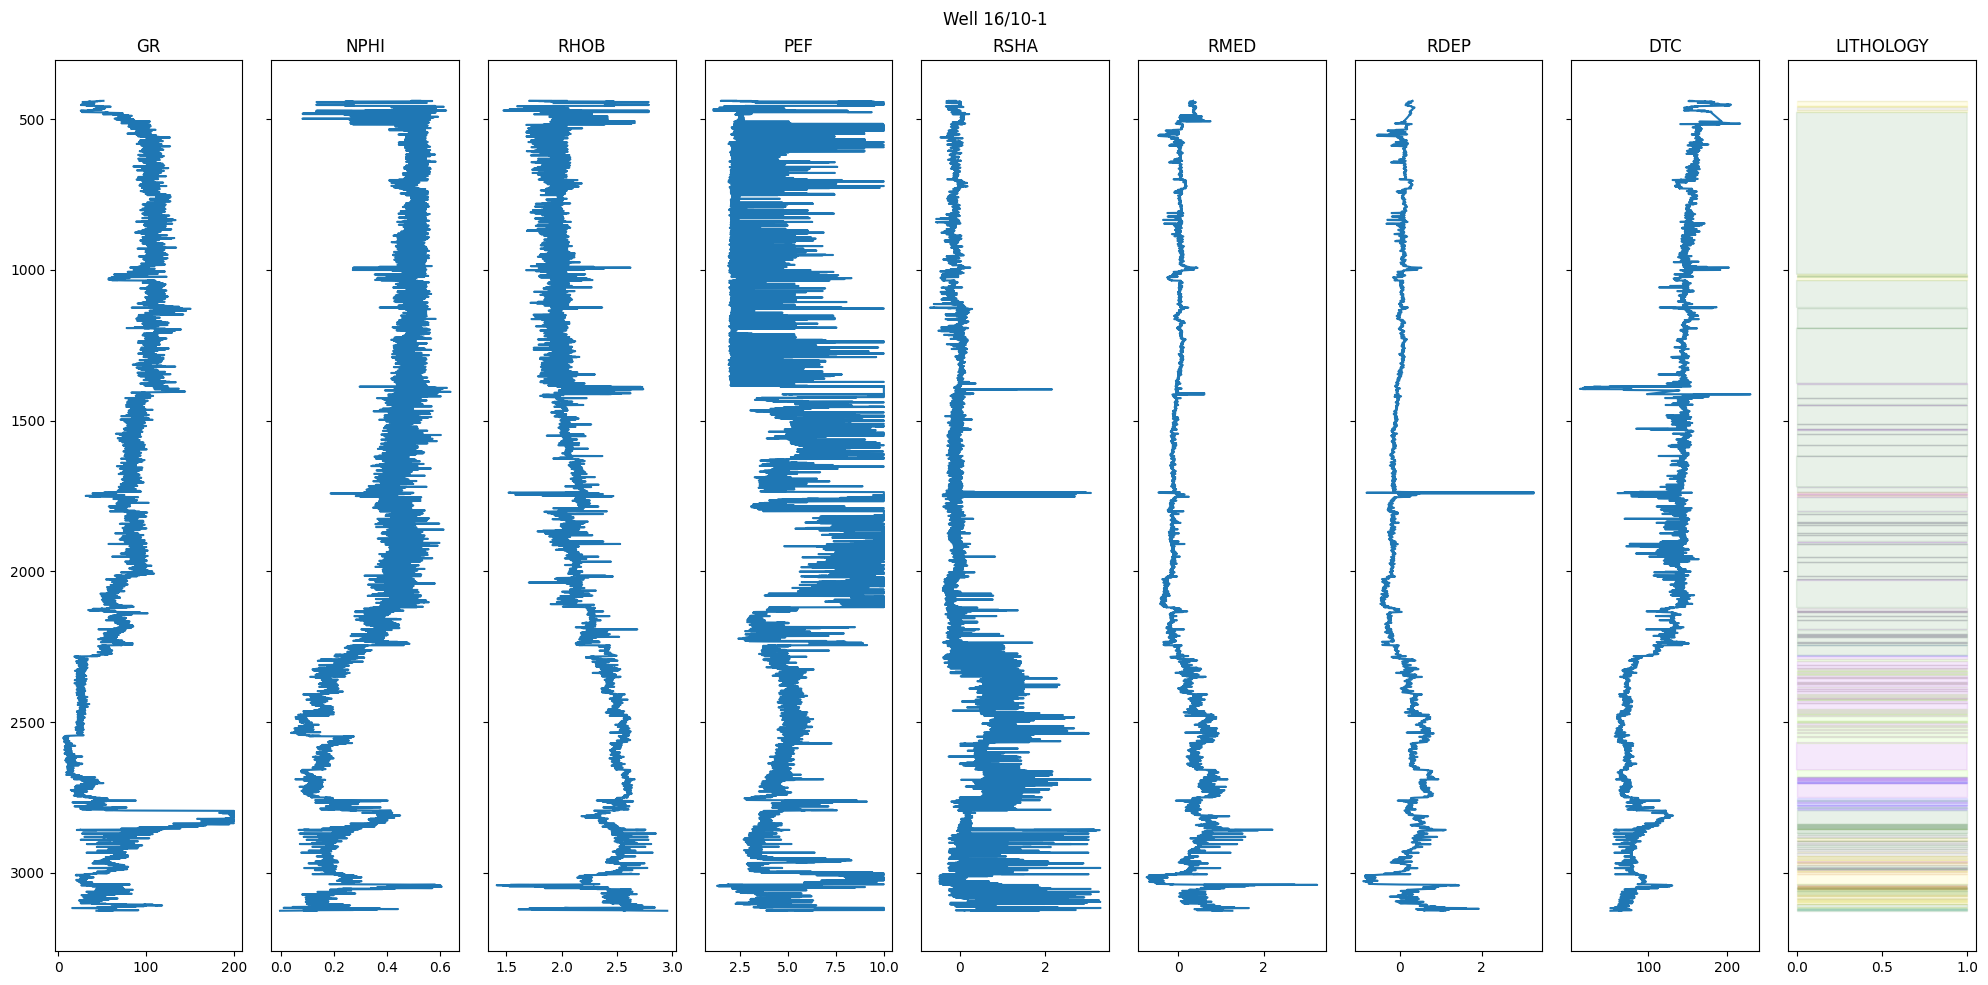

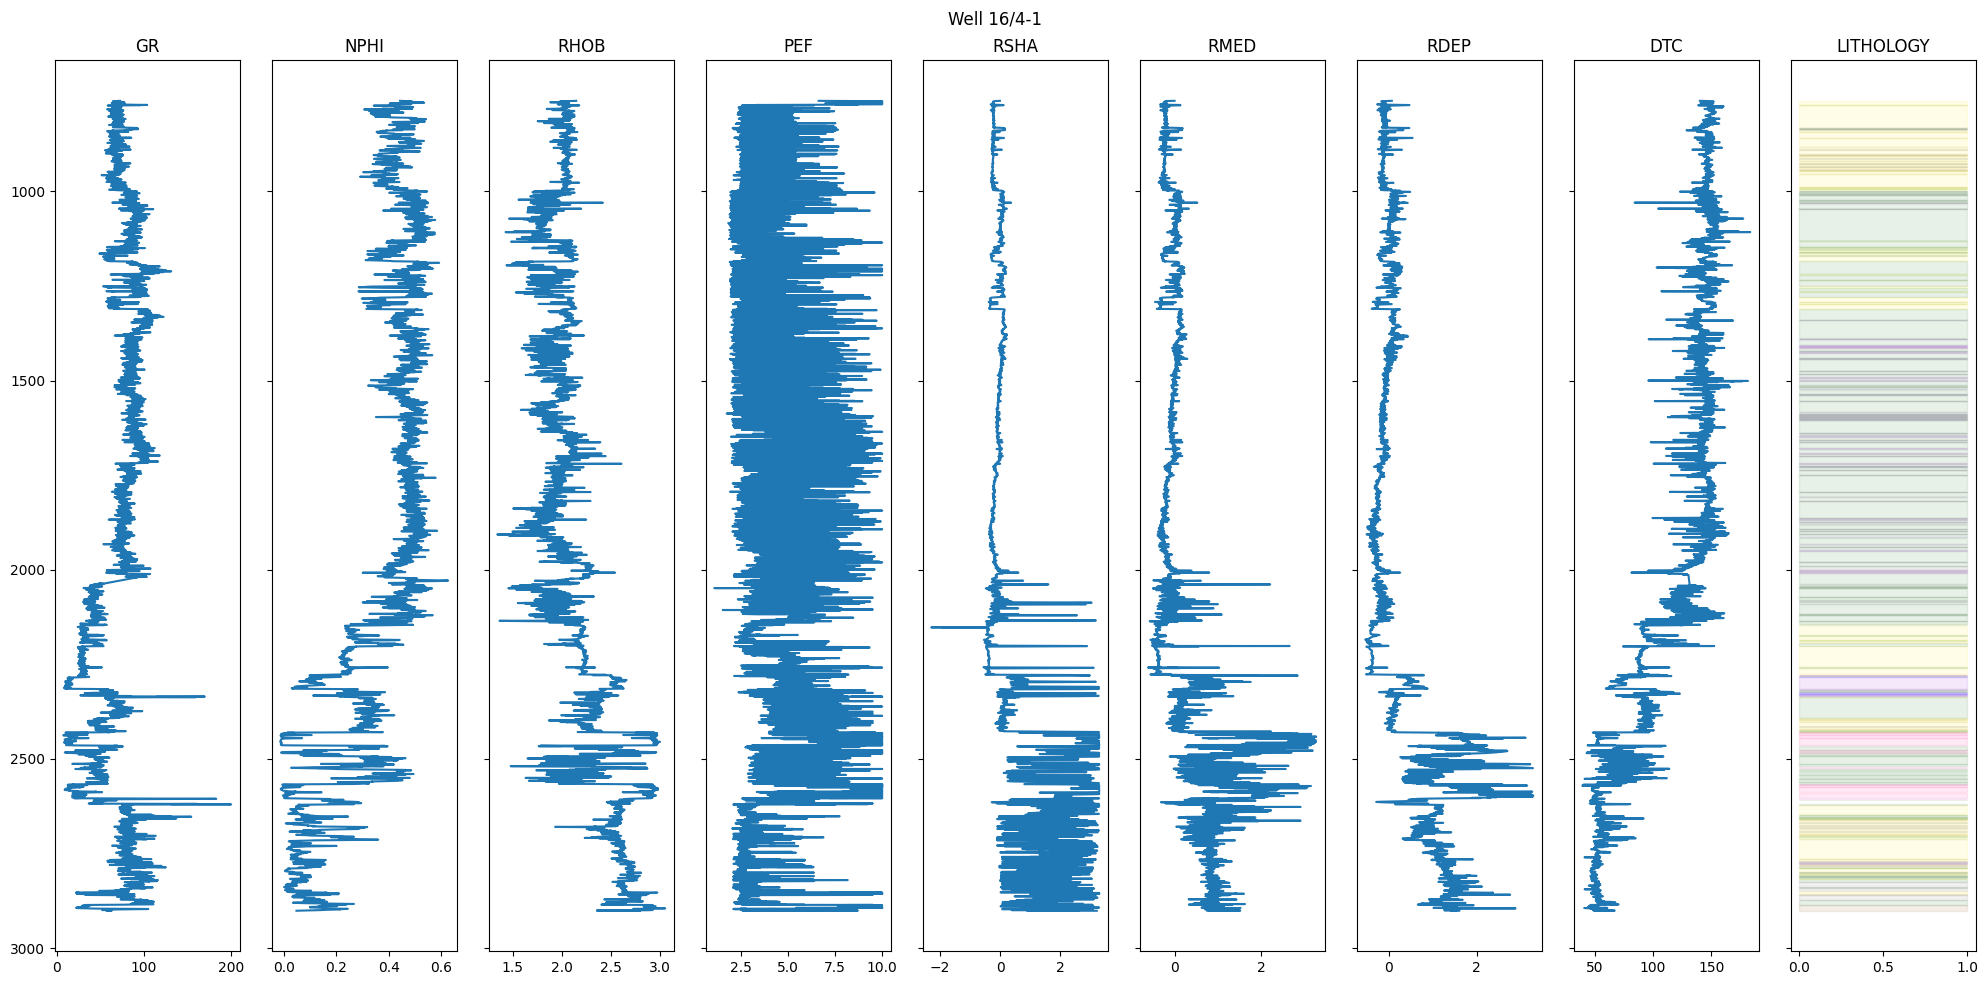

In [98]:
plot_histograms(df_imputed,features)
plot_wells_histograms(df_imputed,wells,features)
plot_wells_curves(df_imputed,wells,features + [target],target)

In [103]:
# StratifiedGroupKFold(n_splits=3)


y = df_imputed[target]
x = df_imputed[features]


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y)



In [106]:

classifier = DecisionTreeClassifier(class_weight="balanced",random_state=42)

classifier.fit(x,y)




,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

{'0': {'f1-score': 1.0, 'precision': 1.0, 'recall': 1.0, 'support': 2085.0},
 '1': {'f1-score': 1.0, 'precision': 1.0, 'recall': 1.0, 'support': 745.0},
 '10': {'f1-score': 1.0, 'precision': 1.0, 'recall': 1.0, 'support': 10.0},
 '11': {'f1-score': 1.0, 'precision': 1.0, 'recall': 1.0, 'support': 20.0},
 '2': {'f1-score': 1.0, 'precision': 1.0, 'recall': 1.0, 'support': 8747.0},
 '3': {'f1-score': 1.0, 'precision': 1.0, 'recall': 1.0, 'support': 234.0},
 '4': {'f1-score': 1.0, 'precision': 1.0, 'recall': 1.0, 'support': 65.0},
 '5': {'f1-score': 1.0, 'precision': 1.0, 'recall': 1.0, 'support': 1047.0},
 '6': {'f1-score': 1.0, 'precision': 1.0, 'recall': 1.0, 'support': 391.0},
 '7': {'f1-score': 1.0, 'precision': 1.0, 'recall': 1.0, 'support': 4.0},
 '8': {'f1-score': 1.0, 'precision': 1.0, 'recall': 1.0, 'support': 100.0},
 '9': {'f1-score': 1.0, 'precision': 1.0, 'recall': 1.0, 'support': 101.0},
 'accuracy': 1.0,
 'macro avg': {'f1-score': 1.0,
               'precision': 1.0,
     

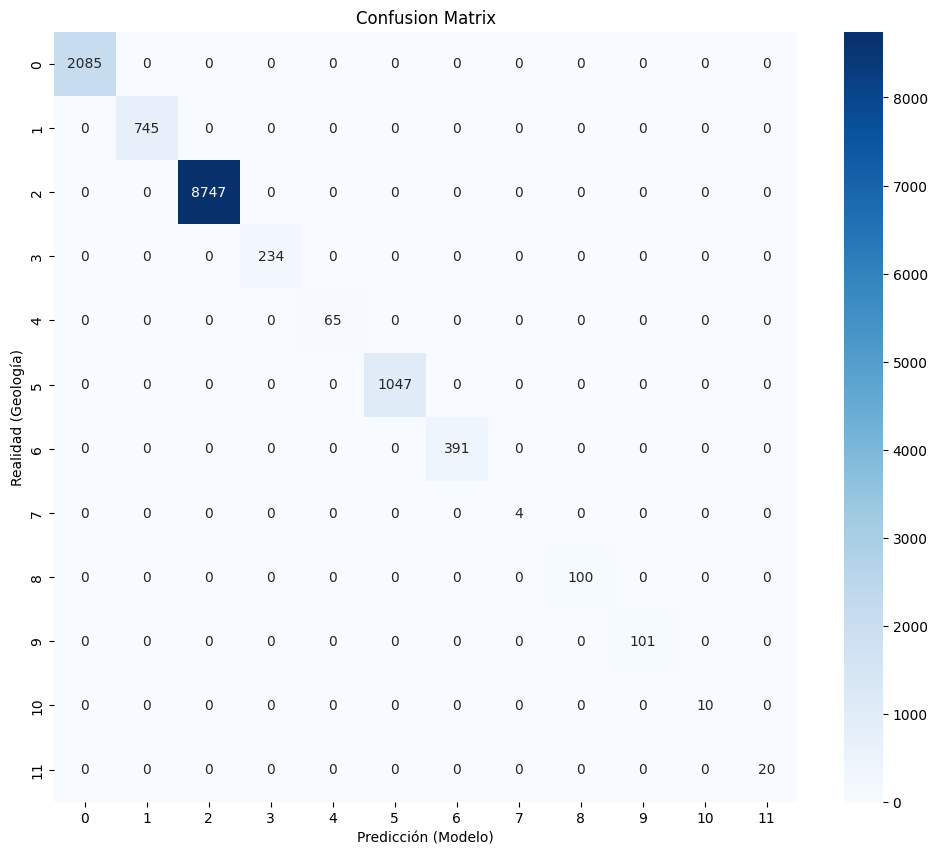

In [107]:
y_test_pred = classifier.predict(x_test)


report = classification_report(y_test,y_test_pred,output_dict=True)
from pprint import pprint
pprint(report)

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicción (Modelo)')
plt.ylabel('Realidad (Geología)')
plt.show()